# SECTION 1 — INSTALL & IMPORT

In [ ]:
import subprocess, sys

def install(pkg):
    try:
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
        print(f'{pkg}')
    except subprocess.CalledProcessError:
        print(f'{pkg} failed — skipping')

pkgs = ['yfinance','pandas','numpy','matplotlib','seaborn','ta',
        'hmmlearn','scikit-learn','scipy','statsmodels','fastapi','uvicorn','pydantic']
print('Installing packages...')
for p in pkgs: install(p)
print('\nDone!')

Installing packages...
yfinance
pandas
numpy
matplotlib
seaborn
ta
hmmlearn
scikit-learn
scipy
statsmodels
fastapi
uvicorn
pydantic

Done!


In [ ]:
# ============================================================
# SECTION 1.2 — Install safety check + Import All Libraries
# ============================================================

# Safety install — runs fast if already installed, fixes if missing
import subprocess, sys

def _ensure(pkg, import_name=None):
    """Install pkg if not already importable."""
    name = import_name or pkg
    try:
        __import__(name)
    except ImportError:
        print(f'  Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f' {pkg} installed.')

_ensure('ta')
_ensure('hmmlearn')
_ensure('yfinance')
_ensure('seaborn')
_ensure('statsmodels')
_ensure('scikit-learn', 'sklearn')

# ── Core ──────────────────────────────────────────────────────
import os, warnings, pickle, json
from datetime import datetime
from collections import Counter
warnings.filterwarnings('ignore')

# ── Data ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import yfinance as yf

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Technical Analysis ────────────────────────────────────────
from ta.trend import MACD, SMAIndicator, EMAIndicator
from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator
from ta.volatility import AverageTrueRange, BollingerBands

# ── Machine Learning ──────────────────────────────────────────
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# ── Statistics ────────────────────────────────────────────────
import statsmodels.api as sm

# ── Plot settings ─────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['figure.dpi']    = 100
sns.set_style('darkgrid')

# ── Reproducibility ───────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Global config ─────────────────────────────────────────────
INITIAL_CAPITAL = 100000   # Default ₹1,00,000 — change freely
RISK_FREE_RATE  = 0.05     # 5% annual risk-free rate

print(' All libraries imported successfully.')
print(f' Default initial capital : ₹{INITIAL_CAPITAL:,}')
print(f' Started                 : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

  Installing ta...
 ta installed.
  Installing hmmlearn...
 hmmlearn installed.
 All libraries imported successfully.
 Default initial capital : ₹100,000
 Started                 : 2026-03-02 14:48:11


# SECTION 2 — DATA COLLECTION

In [ ]:
# ============================================================
# SECTION 2.1 — Download OHLCV Data (Independent per Index)
# Each index keeps its OWN full date range — no forced alignment
# Alignment happens ONLY at portfolio stage (Section 9)
# ============================================================

START_DATE = '2000-01-01'
END_DATE   = '2026-01-01'

def download_data(ticker, start, end, name):
    """Download OHLCV, flatten MultiIndex, forward-fill gaps."""
    print(f'⬇  Downloading {name} ({ticker})...')
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)

    # ── Flatten MultiIndex columns ────────────────────────────
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]
    df.columns = [c.capitalize() for c in df.columns]

    # ── Remove completely empty rows only ─────────────────────
    df.dropna(how='all', inplace=True)

    # ── Fill small gaps (holidays/weekends) with ffill ────────
    df.ffill(inplace=True)

    print(f'    {name}: {len(df)} rows | {df.index[0].date()} → {df.index[-1].date()}')
    return df

df_nifty = download_data('^NSEI',  START_DATE, END_DATE, 'NIFTY 50')
df_sp500 = download_data('^GSPC',  START_DATE, END_DATE, 'S&P 500')

print(f'\n NIFTY 50: {len(df_nifty)} trading days')
print(f' S&P 500 : {len(df_sp500)} trading days')
print('\n  Note: HMMs trained independently on each index full date range.')
print('   Date alignment only happens at portfolio stage (Section 9).')

⬇  Downloading NIFTY 50 (^NSEI)...
    NIFTY 50: 4487 rows | 2007-09-17 → 2025-12-31
⬇  Downloading S&P 500 (^GSPC)...
    S&P 500: 6539 rows | 2000-01-03 → 2025-12-31

 NIFTY 50: 4487 trading days
 S&P 500 : 6539 trading days

  Note: HMMs trained independently on each index full date range.
   Date alignment only happens at portfolio stage (Section 9).


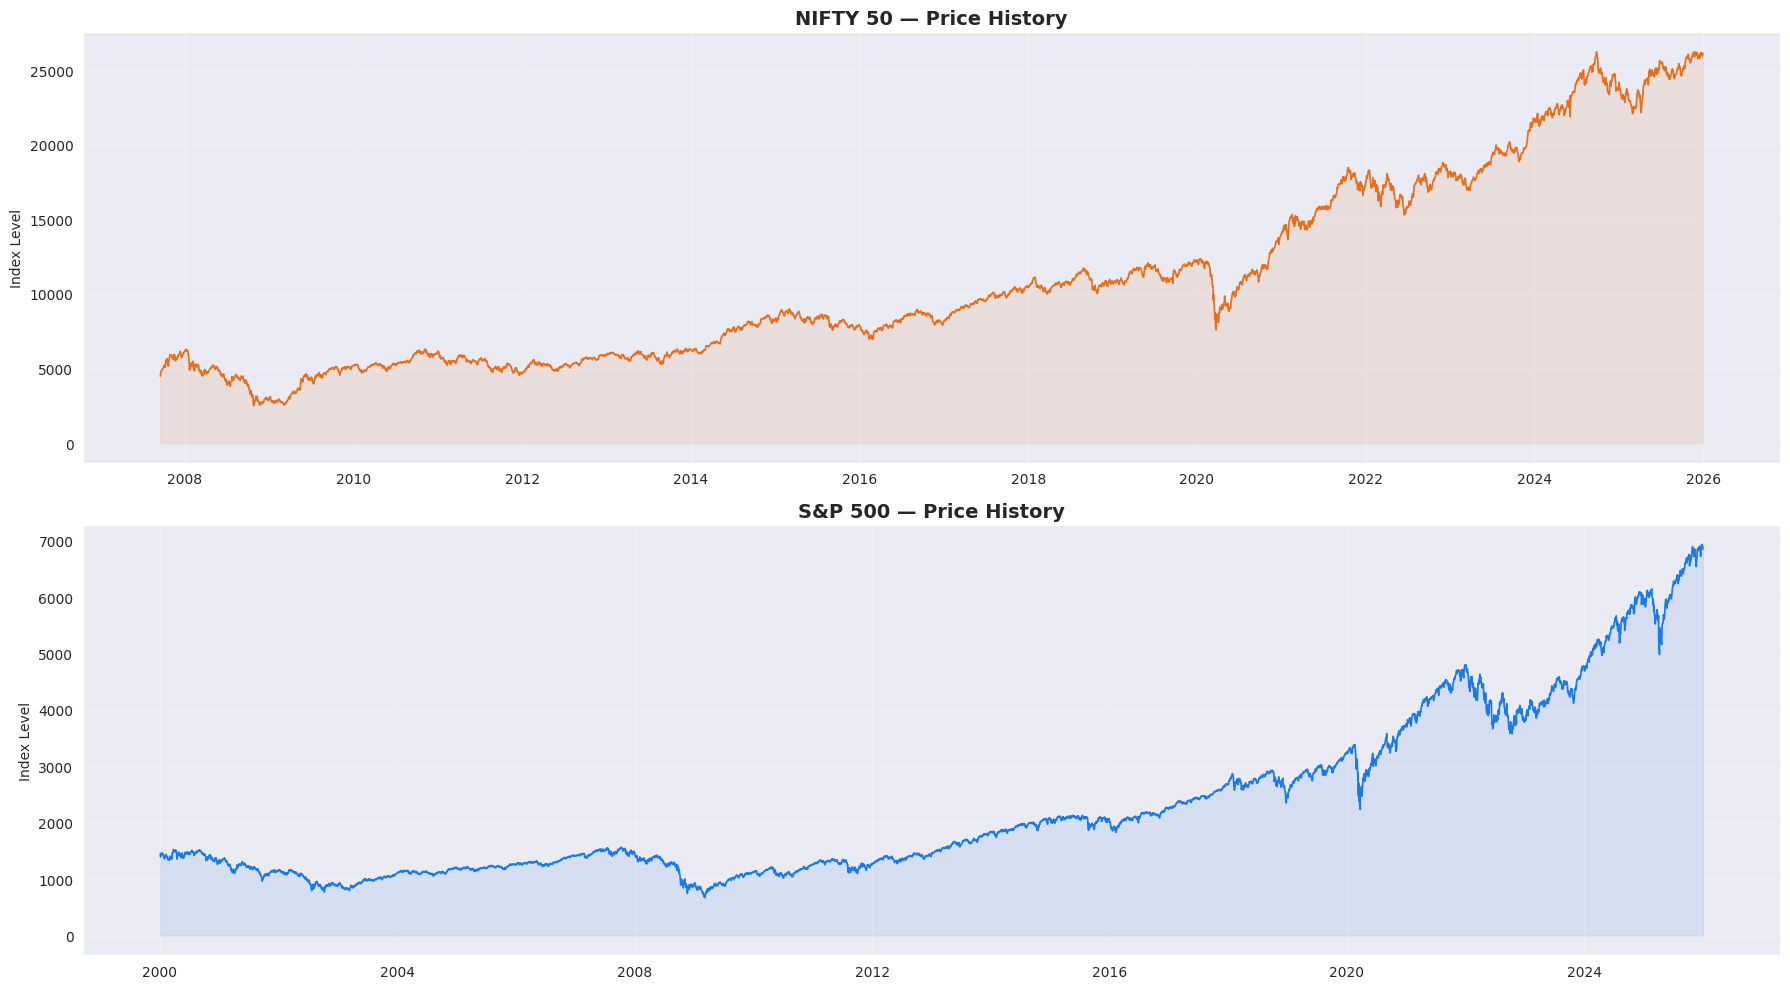

In [ ]:
fig, axes = plt.subplots(2,1,figsize=(18,10))
axes[0].plot(df_nifty.index, df_nifty['Close'], color='#E86E1C', linewidth=1.2)
axes[0].fill_between(df_nifty.index, df_nifty['Close'], alpha=0.1, color='#E86E1C')
axes[0].set_title('NIFTY 50 — Price History', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Index Level'); axes[0].grid(True, alpha=0.3)

axes[1].plot(df_sp500.index, df_sp500['Close'], color='#1C7AE8', linewidth=1.2)
axes[1].fill_between(df_sp500.index, df_sp500['Close'], alpha=0.1, color='#1C7AE8')
axes[1].set_title('S&P 500 — Price History', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Index Level'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('price_history.png', dpi=150, bbox_inches='tight')
plt.show()

# SECTION 3 — FEATURE ENGINEERING

In [ ]:
# ============================================================
# SECTION 3.1 — Feature Engineering with Smart NaN Filling
#
# Strategy instead of dropna():
#   Rolling indicators  → ffill then bfill (carry first valid backward)
#   Returns             → fill 0 (no change on missing day)
#   RSI                 → fill neutral value 50
#   MACD / oscillators  → fill 0
#   Volatility          → fill with expanding mean
# This recovers ~1000+ rows that dropna() would discard.
# ============================================================

def smart_fill(series, method='ffill', neutral=0.0):
    """Fill NaN using specified method then backfill any remaining leading NaN."""
    if method == 'ffill':
        return series.ffill().bfill()
    elif method == 'neutral':
        return series.fillna(neutral).ffill().bfill()
    elif method == 'expanding':
        return series.fillna(series.expanding().mean()).ffill().bfill()
    return series.ffill().bfill()


def engineer_features(df_price, df_benchmark=None, label='Asset'):
    """
    Build 50+ features with smart NaN filling.
    No dropna() — recovers all available rows.
    """
    df    = df_price.copy()
    close = df['Close']
    high  = df['High']
    low   = df['Low']
    vol   = df['Volume']

    # ── Returns & Volatility ─────────────────────────────────
    df['daily_return']    = close.pct_change().fillna(0)
    df['log_return']      = np.log(close / close.shift(1)).fillna(0)
    df['vol_10']          = smart_fill(df['daily_return'].rolling(10).std() * np.sqrt(252), 'expanding')
    df['vol_20']          = smart_fill(df['daily_return'].rolling(20).std() * np.sqrt(252), 'expanding')
    df['vol_50']          = smart_fill(df['daily_return'].rolling(50).std() * np.sqrt(252), 'expanding')
    df['rolling_skew_20'] = smart_fill(df['daily_return'].rolling(20).skew(), 'neutral', 0.0)
    df['rolling_kurt_20'] = smart_fill(df['daily_return'].rolling(20).kurt(), 'neutral', 0.0)

    # ── Trend Features ───────────────────────────────────────
    for w in [10, 20, 50, 100, 200]:
        sma = smart_fill(SMAIndicator(close, window=w).sma_indicator(), 'ffill')
        df[f'sma_{w}'] = sma
        df[f'price_sma_{w}_ratio'] = (close / sma).replace([np.inf, -np.inf], 1.0).fillna(1.0)

    for w in [20, 50]:
        df[f'ema_{w}'] = smart_fill(EMAIndicator(close, window=w).ema_indicator(), 'ffill')

    df['sma_cross_10_50']  = np.where(df['sma_10']  > df['sma_50'],  1, -1)
    df['sma_cross_50_200'] = np.where(df['sma_50']  > df['sma_200'], 1, -1)
    df['ema_cross_20_50']  = np.where(df['ema_20']  > df['ema_50'],  1, -1)

    # ── Momentum Indicators ──────────────────────────────────
    df['rsi_14']      = smart_fill(RSIIndicator(close, window=14).rsi(), 'neutral', 50.0)

    macd_obj          = MACD(close)
    df['macd']        = smart_fill(macd_obj.macd(),        'neutral', 0.0)
    df['macd_signal'] = smart_fill(macd_obj.macd_signal(), 'neutral', 0.0)
    df['macd_diff']   = smart_fill(macd_obj.macd_diff(),   'neutral', 0.0)

    stoch             = StochasticOscillator(high, low, close)
    df['stoch_k']     = smart_fill(stoch.stoch(),        'neutral', 50.0)
    df['stoch_d']     = smart_fill(stoch.stoch_signal(), 'neutral', 50.0)

    df['roc_10']      = smart_fill(ROCIndicator(close, window=10).roc(), 'neutral', 0.0)
    df['roc_20']      = smart_fill(ROCIndicator(close, window=20).roc(), 'neutral', 0.0)
    df['momentum_10'] = (close - close.shift(10)).fillna(0)
    df['momentum_20'] = (close - close.shift(20)).fillna(0)

    # ── Risk Indicators ──────────────────────────────────────
    df['atr_14']        = smart_fill(AverageTrueRange(high,low,close,window=14).average_true_range(), 'expanding')

    def rolling_max_dd(returns, window=20):
        cum = (1 + returns).cumprod()
        dd  = (cum - cum.rolling(window).max()) / (cum.rolling(window).max() + 1e-9)
        return dd.rolling(window).min()

    df['rolling_mdd_20'] = smart_fill(rolling_max_dd(df['daily_return']), 'neutral', 0.0)

    if df_benchmark is not None:
        bench_ret = df_benchmark['Close'].pct_change().reindex(df.index).fillna(0)
        cov_s     = df['daily_return'].rolling(60).cov(bench_ret)
        var_s     = bench_ret.rolling(60).var()
        df['rolling_beta_60'] = smart_fill((cov_s / (var_s + 1e-9)), 'neutral', 1.0)
    else:
        df['rolling_beta_60'] = 1.0

    # ── Bollinger Bands ──────────────────────────────────────
    bb = BollingerBands(close, window=20, window_dev=2)
    df['bb_upper']  = smart_fill(bb.bollinger_hband(), 'ffill')
    df['bb_lower']  = smart_fill(bb.bollinger_lband(), 'ffill')
    df['bb_middle'] = smart_fill(bb.bollinger_mavg(),  'ffill')
    df['bb_pct']    = smart_fill(bb.bollinger_pband(), 'neutral', 0.5)
    df['bb_width']  = smart_fill(
        (df['bb_upper'] - df['bb_lower']) / (df['bb_middle'] + 1e-9), 'expanding')

    # ── Regime Features ──────────────────────────────────────
    df['vol_ratio']      = (df['vol_10'] / (df['vol_50'] + 1e-9)).fillna(1.0)
    df['trend_strength'] = (df['price_sma_20_ratio'] - 1).abs().fillna(0)
    df['vol_cluster']    = (df['vol_10'] > df['vol_10'].rolling(50).mean().bfill()).astype(int)
    df['above_sma200']   = (close > df['sma_200']).astype(int)

    # ── Volume Features ──────────────────────────────────────
    df['vol_sma_20']    = smart_fill(vol.rolling(20).mean(), 'expanding')
    df['vol_ratio_20']  = (vol / (df['vol_sma_20'] + 1e-9)).fillna(1.0)


    # Multi-timeframe return features for ML model and MTM strategy
    df['ret_1m']          = close.pct_change(21).fillna(0)
    df['ret_3m']          = close.pct_change(63).fillna(0)
    df['ret_6m']          = close.pct_change(126).fillna(0)
    df['ret_12m']         = close.pct_change(252).fillna(0)
    df['price_zscore_20'] = ((close - close.rolling(20).mean()) / (close.rolling(20).std() + 1e-9)).fillna(0)
    df['price_zscore_60'] = ((close - close.rolling(60).mean()) / (close.rolling(60).std() + 1e-9)).fillna(0)
    df['high_low_ratio']  = (high / (low + 1e-9)).fillna(1.0)
    df['close_range_pct'] = ((close - low) / (high - low + 1e-9)).fillna(0.5)

    # ── Final safety fill — no NaN should remain ─────────────
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    df.fillna(0, inplace=True)

    nan_count = df.isnull().sum().sum()
    print(f' [{label}] Features: {df.shape[1]} cols | {df.shape[0]} rows | Remaining NaN: {nan_count}')
    return df


print('  Engineering features for NIFTY 50...')
df_nifty_feat = engineer_features(df_nifty, df_sp500, label='NIFTY 50')

print('\n  Engineering features for S&P 500...')
df_sp500_feat = engineer_features(df_sp500, df_nifty, label='S&P 500')

# Export raw features
os.makedirs('quantwise_outputs', exist_ok=True)
df_nifty_feat.to_csv('quantwise_outputs/nifty_features.csv')
df_sp500_feat.to_csv('quantwise_outputs/sp500_features.csv')
print('\n Feature CSVs saved.')

  Engineering features for NIFTY 50...
 [NIFTY 50] Features: 59 cols | 4487 rows | Remaining NaN: 0

  Engineering features for S&P 500...
 [S&P 500] Features: 59 cols | 6539 rows | Remaining NaN: 0

 Feature CSVs saved.


In [ ]:
# SECTION 3.2 — Feature Data Preview

print(f'NIFTY 50  — Shape: {df_nifty_feat.shape}  ({df_nifty_feat.shape[0]} rows x {df_nifty_feat.shape[1]} cols)')
print(f'S&P 500   — Shape: {df_sp500_feat.shape}  ({df_sp500_feat.shape[0]} rows x {df_sp500_feat.shape[1]} cols)')

print('\nAll 59 Feature Columns:')
for i, col in enumerate(df_nifty_feat.columns, 1):
    print(f'  {i:>2}. {col}')

print('\nNIFTY 50 — First 10 Rows:')
display(df_nifty_feat.head(10))

print('\nS&P 500 — First 10 Rows:')
display(df_sp500_feat.head(10))

NIFTY 50  — Shape: (4487, 61)  (4487 rows x 61 cols)
S&P 500   — Shape: (6539, 61)  (6539 rows x 61 cols)

All 59 Feature Columns:
   1. Close
   2. High
   3. Low
   4. Open
   5. Volume
   6. daily_return
   7. log_return
   8. vol_10
   9. vol_20
  10. vol_50
  11. rolling_skew_20
  12. rolling_kurt_20
  13. sma_10
  14. price_sma_10_ratio
  15. sma_20
  16. price_sma_20_ratio
  17. sma_50
  18. price_sma_50_ratio
  19. sma_100
  20. price_sma_100_ratio
  21. sma_200
  22. price_sma_200_ratio
  23. ema_20
  24. ema_50
  25. sma_cross_10_50
  26. sma_cross_50_200
  27. ema_cross_20_50
  28. rsi_14
  29. macd
  30. macd_signal
  31. macd_diff
  32. stoch_k
  33. stoch_d
  34. roc_10
  35. roc_20
  36. momentum_10
  37. momentum_20
  38. atr_14
  39. rolling_mdd_20
  40. rolling_beta_60
  41. bb_upper
  42. bb_lower
  43. bb_middle
  44. bb_pct
  45. bb_width
  46. vol_ratio
  47. trend_strength
  48. vol_cluster
  49. above_sma200
  50. vol_sma_20
  51. vol_ratio_20
  52. ret_1m
  53.

,Close,High,Low,Open,Volume,daily_return,log_return,vol_10,vol_20,vol_50,...,ret_1m,ret_3m,ret_6m,ret_12m,price_zscore_20,price_zscore_60,high_low_ratio,close_range_pct,hmm_state,regime
Date,,,,,,,,,,,,,,,,,,,,,
2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0,0.000000,0.000000,0.202874,0.292463,0.331446,...,0.0,0.0,0.0,0.0,0.0,0.0,1.014767,0.178246,1,Weak Sideways
2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0,0.011469,0.011404,0.202874,0.292463,0.331446,...,0.0,0.0,0.0,0.0,0.0,0.0,1.015675,0.920290,1,Weak Sideways
2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0,0.040946,0.040130,0.202874,0.292463,0.331446,...,0.0,0.0,0.0,0.0,0.0,0.0,1.041481,0.964769,1,Weak Sideways
2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0,0.003212,0.003207,0.202874,0.292463,0.331446,...,0.0,0.0,0.0,0.0,0.0,0.0,1.008409,0.664982,1,Weak Sideways
2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0,0.018957,0.018780,0.202874,0.292463,0.331446,...,0.0,0.0,0.0,0.0,0.0,0.0,1.025773,0.851226,1,Weak Sideways
2007-09-24,4932.200195,4941.149902,4837.149902,4837.149902,0,0.019566,0.019377,0.202874,0.292463,0.331446,...,0.0,0.0,0.0,0.0,0.0,0.0,1.021500,0.913945,3,Weak Sideways
2007-09-25,4938.850098,4953.899902,4878.149902,4939.100098,0,0.001348,0.001347,0.202874,0.292463,0.331446,...,0.0,0.0,0.0,0.0,0.0,0.0,1.015528,0.801323,3,Weak Sideways
2007-09-26,4940.500000,4980.850098,4930.350098,4937.600098,0,0.000334,0.000334,0.202874,0.292463,0.331446,...,0.0,0.0,0.0,0.0,0.0,0.0,1.010243,0.200988,3,Weak Sideways
2007-09-27,5000.549805,5016.399902,4942.700195,4942.700195,0,0.012155,0.012081,0.202874,0.292463,0.331446,...,0.0,0.0,0.0,0.0,0.0,0.0,1.014911,0.784937,3,Weak Sideways



S&P 500 — First 10 Rows:


,Close,High,Low,Open,Volume,daily_return,log_return,vol_10,vol_20,vol_50,...,ret_1m,ret_3m,ret_6m,ret_12m,price_zscore_20,price_zscore_60,high_low_ratio,close_range_pct,hmm_state,regime
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000,0.000000,0.000000,0.278955,0.258414,0.23197,...,0.0,0.0,0.0,0.0,0.0,0.0,1.027559,0.425327,3,Weak Sideways
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000,-0.038345,-0.039099,0.278955,0.258414,0.23197,...,0.0,0.0,0.0,0.0,0.0,0.0,1.041354,0.034435,3,Weak Sideways
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000,0.001922,0.001920,0.278955,0.258414,0.23197,...,0.0,0.0,0.0,0.0,0.0,0.0,1.025833,0.686428,3,Weak Sideways
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000,0.000956,0.000955,0.278955,0.258414,0.23197,...,0.0,0.0,0.0,0.0,0.0,0.0,1.014223,0.573230,3,Weak Sideways
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000,0.027090,0.026730,0.278955,0.258414,0.23197,...,0.0,0.0,0.0,0.0,0.0,0.0,1.029085,1.000000,3,Weak Sideways
2000-01-10,1457.599976,1464.359985,1441.469971,1441.469971,1064800000,0.011190,0.011128,0.278955,0.258414,0.23197,...,0.0,0.0,0.0,0.0,0.0,0.0,1.015880,0.704674,3,Weak Sideways
2000-01-11,1438.560059,1458.660034,1434.420044,1457.599976,1014000000,-0.013063,-0.013149,0.278955,0.258414,0.23197,...,0.0,0.0,0.0,0.0,0.0,0.0,1.016899,0.170793,3,Weak Sideways
2000-01-12,1432.250000,1442.599976,1427.079956,1438.560059,974600000,-0.004386,-0.004396,0.278955,0.258414,0.23197,...,0.0,0.0,0.0,0.0,0.0,0.0,1.010875,0.333121,3,Weak Sideways
2000-01-13,1449.680054,1454.199951,1432.250000,1432.250000,1030400000,0.012170,0.012096,0.278955,0.258414,0.23197,...,0.0,0.0,0.0,0.0,0.0,0.0,1.015326,0.794082,3,Weak Sideways


# SECTION 4 — 6-STATE HMM REGIME DETECTION

In [ ]:
# ============================================================
# SECTION 4.1 — 6-State HMM with Pure Finance Theory Labeling
#
# 6 States:
#   Strong Bull    → high +return + very low vol
#   Weak Bull      → small +return + medium vol
#   Strong Sideways→ ~0 return + low vol
#   Weak Sideways  → ~0 return + high vol (choppy)
#   Weak Bear      → small -return + medium vol
#   Strong Bear    → big -return + very high vol (crash)
#
# Labeling grid:
#              LOW vol      MED vol      HIGH vol
#  ret > hi    StrongBull   WeakBull     WeakBull
#  ret ~ 0     StrongSide   WeakSide     WeakSide
#  ret < lo    WeakBear     WeakBear     StrongBear
# ============================================================

REGIME_COLORS = {
    'Strong Bull':     '#1a7a1a',
    'Weak Bull':       '#6dbf6d',
    'Strong Sideways': '#e6a817',
    'Weak Sideways':   '#f0d080',
    'Weak Bear':       '#e07050',
    'Strong Bear':     '#c0392b'
}

# Regime groupings for strategy assignment
BULL_REGIMES     = ['Strong Bull', 'Weak Bull']
SIDEWAYS_REGIMES = ['Strong Sideways', 'Weak Sideways']
BEAR_REGIMES     = ['Weak Bear', 'Strong Bear']


def classify_6state(stats, ret_hi, ret_lo, vol_hi, vol_med):
    """
    Pure finance theory 2D classification:
      Axes: mean_return (high/neutral/low) x mean_vol (low/med/high)
    """
    r = stats['mean_return']
    v = stats['mean_vol']

    if r > ret_hi:
        return 'Strong Bull' if v < vol_med else 'Weak Bull'
    elif r < ret_lo:
        return 'Strong Bear' if v > vol_hi else 'Weak Bear'
    else:  # neutral return
        return 'Strong Sideways' if v < vol_med else 'Weak Sideways'


def smooth_regimes(regime_series, min_days=10):
    """
    Post-processing: any regime streak shorter than min_days
    gets replaced by its neighboring regime.
    This removes the noisy day-by-day flickering seen in v1.
    """
    regimes  = regime_series.copy()
    values   = regimes.values.tolist()
    n        = len(values)
    i        = 0
    while i < n:
        j = i
        while j < n and values[j] == values[i]:
            j += 1
        streak_len = j - i
        if streak_len < min_days:
            # Replace with previous regime (or next if at start)
            replacement = values[i-1] if i > 0 else (values[j] if j < n else values[i])
            for k in range(i, j):
                values[k] = replacement
        i = j
    return pd.Series(values, index=regimes.index, name=regimes.name)


def train_hmm_6state(df_feat, label='Asset'):
    """
    Train 6-state Gaussian HMM and label each state using
    pure finance theory (return × volatility decision matrix).
    Applies regime smoothing to remove short spurious streaks.
    """
    HMM_FEATURES = ['log_return','vol_10','vol_20','rsi_14','macd_diff',
                    'bb_pct','vol_ratio','trend_strength']
    HMM_FEATURES = [f for f in HMM_FEATURES if f in df_feat.columns]
    X = df_feat[HMM_FEATURES].values

    print(f'  Training 6-state HMM for [{label}] on {len(X)} rows...')

    model = GaussianHMM(
        n_components=6,
        covariance_type='diag',
        n_iter=2000,
        random_state=RANDOM_SEED,
        tol=1e-5,
        verbose=False
    )
    model.fit(X)
    hidden_states = model.predict(X)

    # ── Compute per-state statistics ─────────────────────────
    regime_stats = {}
    for s in range(6):
        mask  = (hidden_states == s)
        sdata = df_feat.loc[df_feat.index[mask]]
        ret   = sdata['daily_return']
        regime_stats[s] = {
            'mean_return': float(ret.mean()),
            'mean_vol':    float(sdata['vol_20'].mean()),
            'sharpe':      float(ret.mean()/(ret.std()+1e-9)*np.sqrt(252)),
            'days':        int(mask.sum())
        }

    # ── Dynamic thresholds from state statistics ──────────────
    all_rets  = [s['mean_return'] for s in regime_stats.values()]
    all_vols  = [s['mean_vol']    for s in regime_stats.values()]

    ret_hi   = np.percentile(all_rets, 67)   # upper third = bull zone
    ret_lo   = np.percentile(all_rets, 33)   # lower third = bear zone
    vol_hi   = np.percentile(all_vols, 75)   # top quarter = high vol
    vol_med  = np.percentile(all_vols, 50)   # median = medium vol

    print(f'   Thresholds → ret_hi={ret_hi*100:+.3f}% ret_lo={ret_lo*100:+.3f}% '
          f'vol_med={vol_med*100:.1f}% vol_hi={vol_hi*100:.1f}%')

    # ── Classify each state ───────────────────────────────────
    regime_map = {}
    for s, stats in regime_stats.items():
        regime_map[s] = classify_6state(stats, ret_hi, ret_lo, vol_hi, vol_med)

    # ── Safety: resolve duplicate labels via return ranking ───
    label_counts = Counter(regime_map.values())
    all_6 = ['Strong Bull','Weak Bull','Strong Sideways','Weak Sideways','Weak Bear','Strong Bear']
    missing = [l for l in all_6 if l not in regime_map.values()]
    for lbl, cnt in label_counts.items():
        if cnt > 1 and missing:
            dup_states = sorted([s for s,l in regime_map.items() if l==lbl],
                                key=lambda s: regime_stats[s]['mean_return'])
            # Reassign the middle duplicate to first missing label
            regime_map[dup_states[len(dup_states)//2]] = missing.pop(0)

    # ── Build regime series ───────────────────────────────────
    raw_regime = pd.Series(
        [regime_map[s] for s in hidden_states],
        index=df_feat.index,
        name='regime'
    )

    # ── Smooth: remove streaks < 10 days ─────────────────────
    smoothed_regime = smooth_regimes(raw_regime, min_days=10)

    # ── Print report ─────────────────────────────────────────
    print(f'\n   {"State":<6} {"Label":<18} {"Ret/day":>12} {"Ann Vol":>9} {"Sharpe":>8} {"Days":>6}')
    print(f'   {"-"*65}')
    for s in range(6):
        lbl   = regime_map[s]
        st    = regime_stats[s]
        emoji = {'Strong Bull':'🟢','Weak Bull':'💚','Strong Sideways':'🟡',
                 'Weak Sideways':'🔶','Weak Bear':'🟠','Strong Bear':'🔴'}.get(lbl,'⚪')
        print(f'   {s:<6} {emoji} {lbl:<16} {st["mean_return"]*100:>+11.4f}% '
              f'{st["mean_vol"]*100:>8.1f}% {st["sharpe"]:>8.2f} {st["days"]:>6}')

    # Check smoothing effect
    raw_changes      = (raw_regime != raw_regime.shift()).sum()
    smoothed_changes = (smoothed_regime != smoothed_regime.shift()).sum()
    print(f'\n    Regime transitions: {raw_changes} raw → {smoothed_changes} after smoothing')

    return model, hidden_states, regime_map, smoothed_regime


# ── Train 6-state HMM independently for each index ───────────
print('='*60)
hmm_nifty, states_nifty, regime_map_nifty, regime_series_nifty = train_hmm_6state(df_nifty_feat, 'NIFTY 50')
df_nifty_feat['hmm_state'] = states_nifty
df_nifty_feat['regime']    = regime_series_nifty

print('\n' + '='*60)
hmm_sp500, states_sp500, regime_map_sp500, regime_series_sp500 = train_hmm_6state(df_sp500_feat, 'S&P 500')
df_sp500_feat['hmm_state'] = states_sp500
df_sp500_feat['regime']    = regime_series_sp500

  Training 6-state HMM for [NIFTY 50] on 4487 rows...


   Thresholds → ret_hi=+0.221% ret_lo=-0.167% vol_med=17.8% vol_hi=32.9%

   State  Label                   Ret/day   Ann Vol   Sharpe   Days
   -----------------------------------------------------------------
   0      🟡 Strong Sideways      -0.0237%     11.5%    -0.53   1087
   1      💚 Weak Bull            +0.6491%     36.6%     5.10    369
   2      🟠 Weak Bear            -0.4344%     14.1%    -7.13    733
   3      🔶 Weak Sideways        +0.1815%     21.5%     2.29    738
   4      🔴 Strong Bear          -0.7766%     39.7%    -3.88    256
   5      🟢 Strong Bull          +0.2943%     12.2%     7.05   1304

    Regime transitions: 528 raw → 132 after smoothing

  Training 6-state HMM for [S&P 500] on 6539 rows...


   Thresholds → ret_hi=+0.176% ret_lo=-0.078% vol_med=17.9% vol_hi=19.3%

   State  Label                   Ret/day   Ann Vol   Sharpe   Days
   -----------------------------------------------------------------
   0      🟠 Weak Bear            -0.5625%     16.5%    -7.43   1010
   1      💚 Weak Bull            +0.3855%     19.4%     6.72   1023
   2      🟢 Strong Bull          +0.1940%      9.4%     6.63   1623
   3      🔶 Weak Sideways        +0.1665%     19.2%     2.32   1174
   4      🔴 Strong Bear          -0.0827%     40.8%    -0.45    523
   5      🟡 Strong Sideways      -0.0757%      9.6%    -1.89   1186

    Regime transitions: 1010 raw → 152 after smoothing


# SECTION 5 — REGIME ANALYSIS

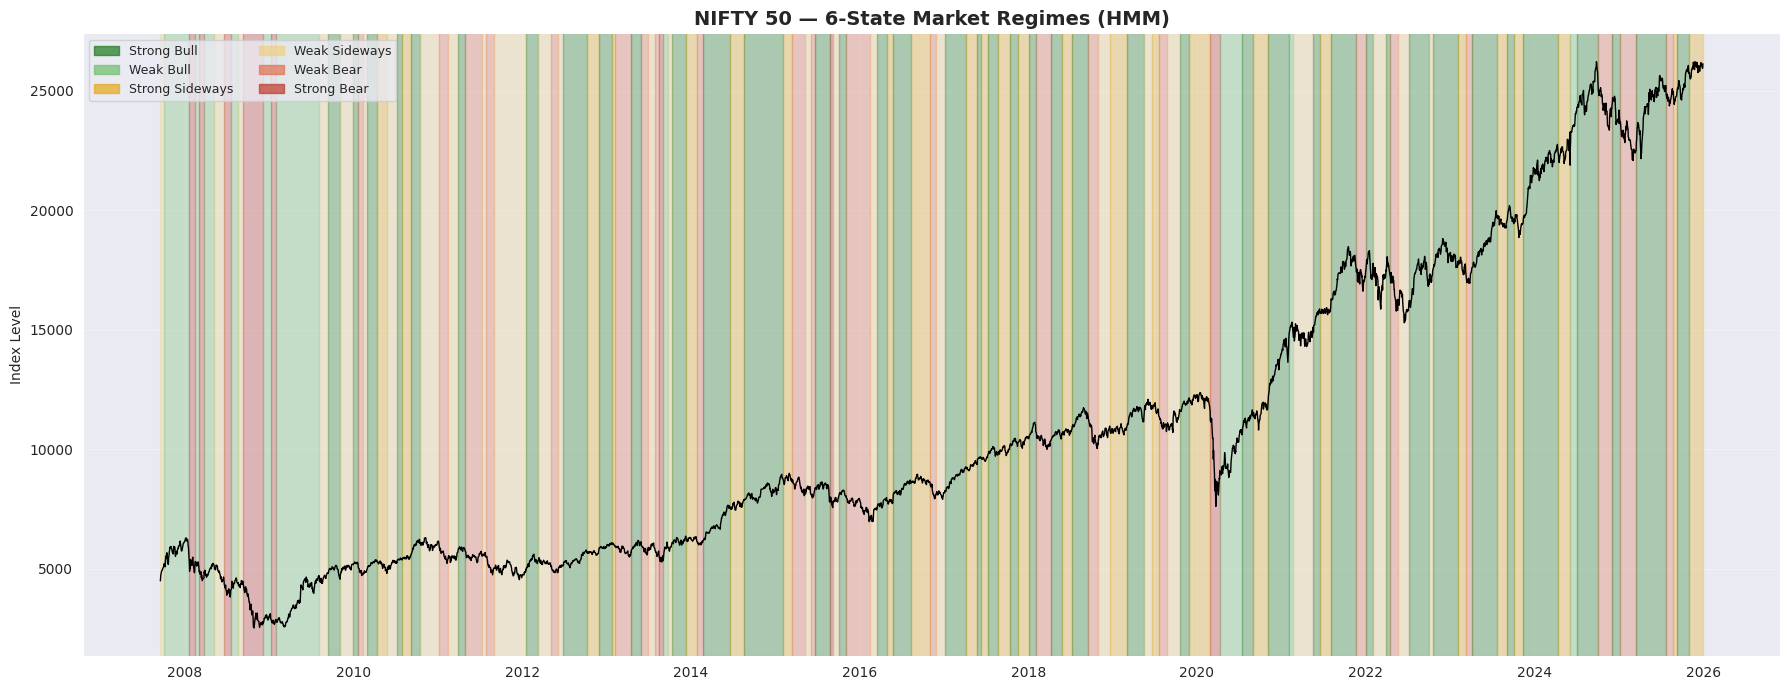

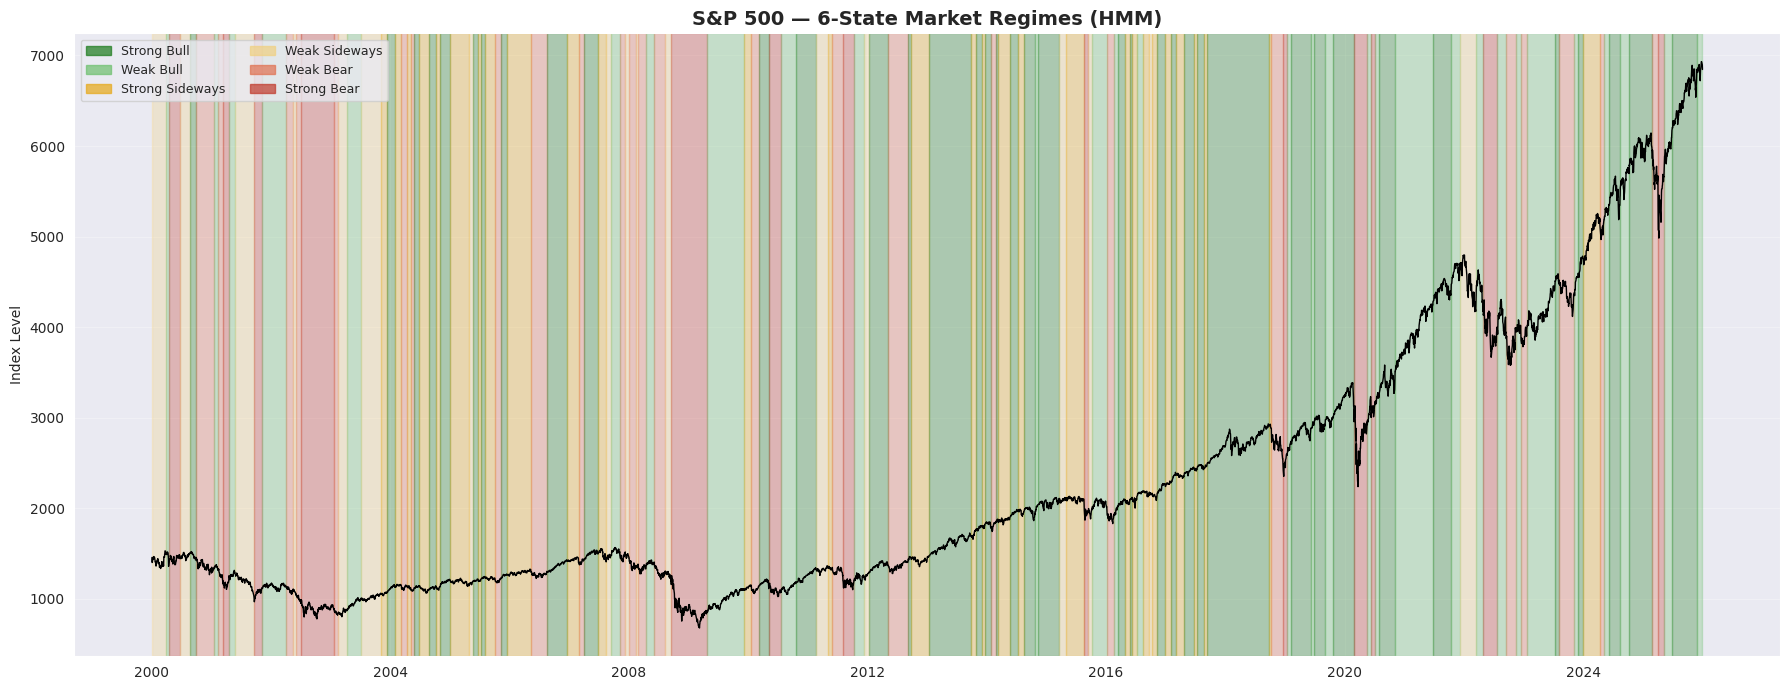

In [ ]:
# ============================================================
# SECTION 5.1 — Price Chart with 6-State Regime Color Overlay
# ============================================================

def plot_regime_overlay(df, title='Regime Overlay'):
    fig, ax = plt.subplots(figsize=(18,7))
    ax.plot(df.index, df['Close'], color='black', linewidth=1, zorder=3)

    prev_date   = df.index[0]
    prev_regime = df['regime'].iloc[0]

    for i in range(1, len(df)):
        cur = df['regime'].iloc[i]
        if cur != prev_regime or i == len(df)-1:
            ax.axvspan(prev_date, df.index[i], alpha=0.3,
                       color=REGIME_COLORS.get(prev_regime, 'grey'))
            prev_date, prev_regime = df.index[i], cur

    patches = [mpatches.Patch(color=REGIME_COLORS[r], label=r, alpha=0.7)
               for r in REGIME_COLORS]
    ax.legend(handles=patches, loc='upper left', fontsize=9, ncol=2)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Index Level'); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(title.replace(' ','_').replace('/','') + '.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_regime_overlay(df_nifty_feat, 'NIFTY 50 — 6-State Market Regimes (HMM)')
plot_regime_overlay(df_sp500_feat, 'S&P 500 — 6-State Market Regimes (HMM)')


  REGIME ANALYSIS — NIFTY 50


,Days,Pct (%),Avg Ret/day (%),Ann Return (%),Ann Vol (%),Sharpe,Avg Duration,Max Duration
Regime,,,,,,,,
Strong Bull,1731,38.6,0.149,45.6,12.6,2.97,42.2,110
Weak Bull,391,8.7,0.417,185.3,33.2,3.17,39.1,127
Strong Sideways,799,17.8,-0.015,-3.7,12.3,-0.31,32.0,63
Weak Sideways,753,16.8,0.104,29.9,20.2,1.30,29.0,89
Weak Bear,642,14.3,-0.220,-42.5,16.3,-3.39,29.2,71
Strong Bear,171,3.8,-0.773,-85.8,57.4,-3.39,21.4,54


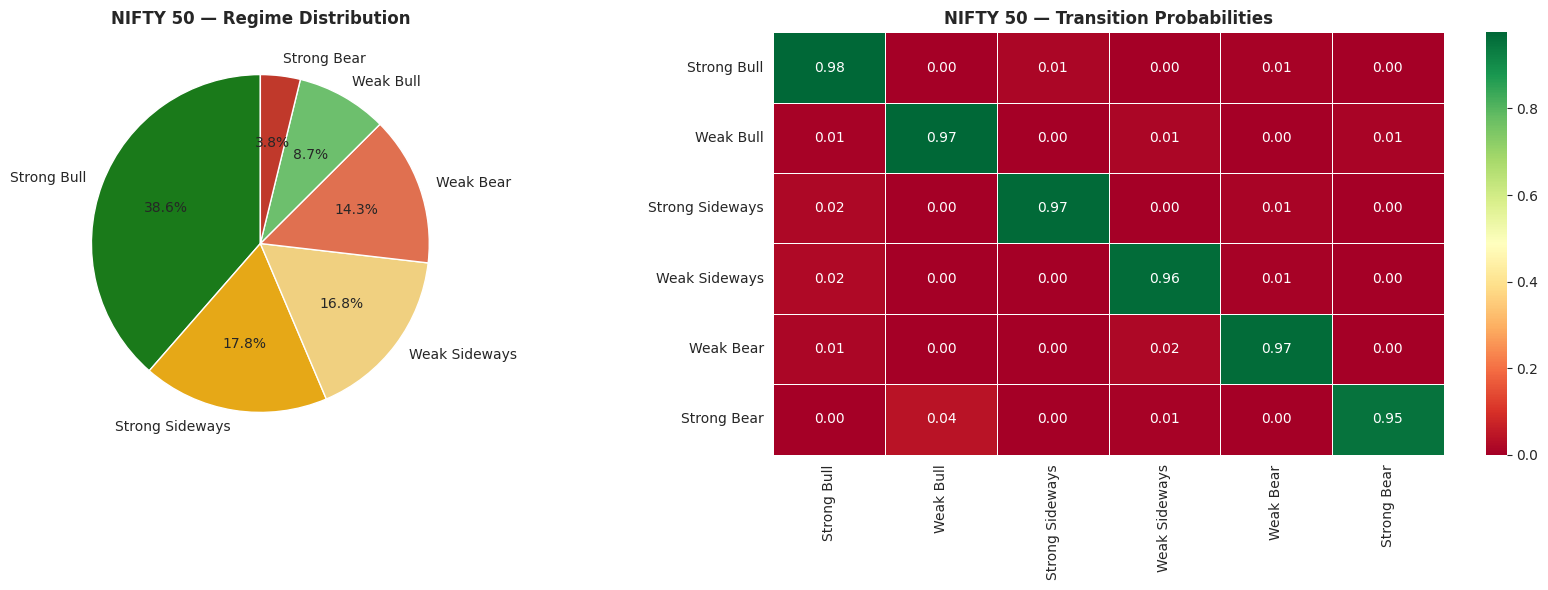


  REGIME ANALYSIS — S&P 500


,Days,Pct (%),Avg Ret/day (%),Ann Return (%),Ann Vol (%),Sharpe,Avg Duration,Max Duration
Regime,,,,,,,,
Strong Bull,2066,31.6,0.090,25.4,11.4,1.98,54.4,262
Weak Bull,1303,19.9,0.141,42.7,15.9,2.24,43.4,158
Strong Sideways,1014,15.5,-0.010,-2.4,11.2,-0.22,35.0,100
Weak Sideways,595,9.1,0.014,3.6,17.9,0.20,35.0,86
Weak Bear,881,13.5,-0.116,-25.4,19.9,-1.48,35.2,86
Strong Bear,680,10.4,-0.091,-20.5,41.6,-0.55,52.3,153


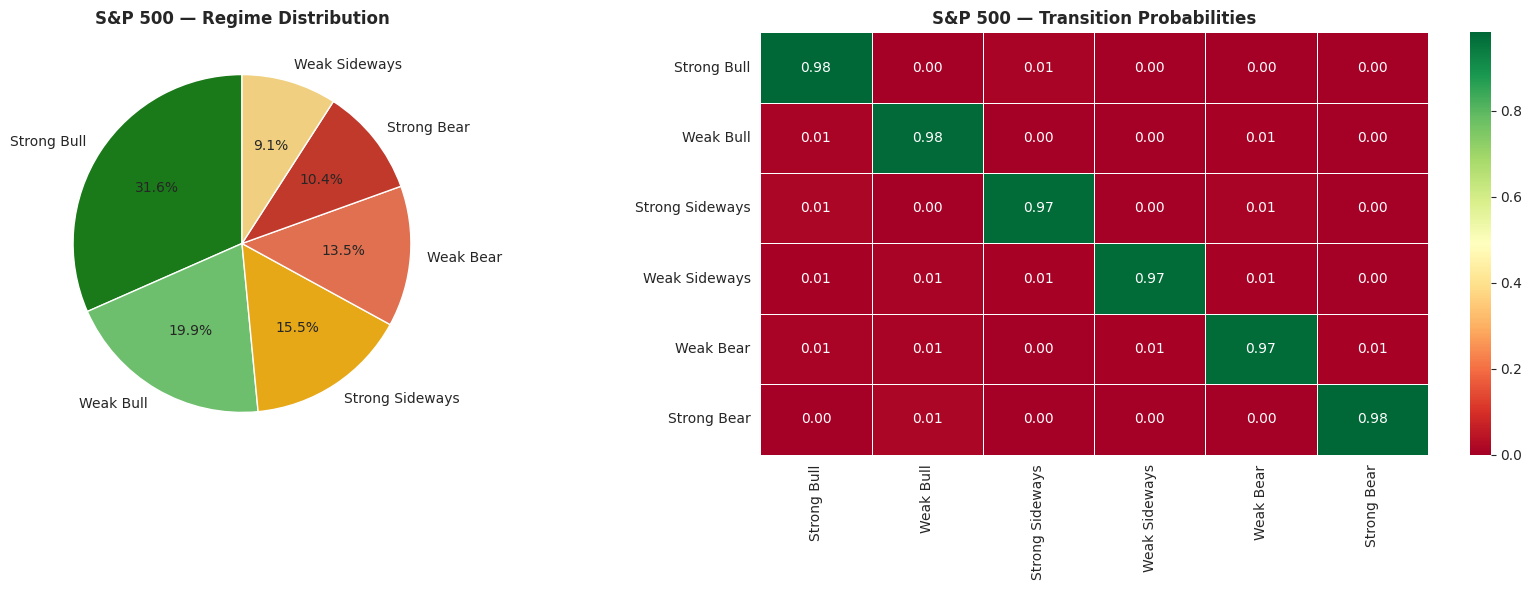

In [ ]:
# ============================================================
# SECTION 5.2 — Regime Statistics & Transition Matrix
# ============================================================

def regime_analysis(df, label='Asset'):
    print(f'\n{"="*65}')
    print(f'  REGIME ANALYSIS — {label}')
    print(f'{"="*65}')

    all_regimes = list(REGIME_COLORS.keys())
    summary = []
    for regime in all_regimes:
        mask = df['regime'] == regime
        if not mask.any(): continue
        ret = df.loc[mask, 'daily_return']
        streaks = (df['regime'] != df['regime'].shift()).cumsum()
        rstreaks = df.loc[mask].groupby(streaks[mask]).size()
        summary.append({
            'Regime': regime,
            'Days': int(mask.sum()),
            'Pct (%)': round(mask.mean()*100,1),
            'Avg Ret/day (%)': round(ret.mean()*100,3),
            'Ann Return (%)': round(((1+ret.mean())**252-1)*100,1),
            'Ann Vol (%)': round(ret.std()*np.sqrt(252)*100,1),
            'Sharpe': round(ret.mean()/(ret.std()+1e-9)*np.sqrt(252),2),
            'Avg Duration': round(rstreaks.mean(),1),
            'Max Duration': int(rstreaks.max())
        })
    smdf = pd.DataFrame(summary).set_index('Regime')
    display(smdf)

    # Transition matrix
    vals = df['regime'].values
    present = [r for r in all_regimes if r in df['regime'].unique()]
    trans = pd.DataFrame(0.0, index=present, columns=present)
    for i in range(len(vals)-1):
        if vals[i] in present and vals[i+1] in present:
            trans.loc[vals[i], vals[i+1]] += 1
    trans = trans.div(trans.sum(axis=1)+1e-9, axis=0).round(3)

    fig, axes = plt.subplots(1,2,figsize=(18,6))
    counts = df['regime'].value_counts()
    colors = [REGIME_COLORS.get(r,'grey') for r in counts.index]
    axes[0].pie(counts.values, labels=counts.index, colors=colors,
                autopct='%1.1f%%', startangle=90)
    axes[0].set_title(f'{label} — Regime Distribution', fontweight='bold')
    sns.heatmap(trans, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1], linewidths=0.5)
    axes[1].set_title(f'{label} — Transition Probabilities', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{label.replace(" ","_")}_regime_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    return smdf, trans

nifty_summary, nifty_trans = regime_analysis(df_nifty_feat, 'NIFTY 50')
sp500_summary, sp500_trans = regime_analysis(df_sp500_feat, 'S&P 500')

# SECTION 6 — STRATEGIES (Original 10 + Phase 1: 4 High-Alpha)

In [ ]:
# ============================================================
# SECTION 6.1 — All 10 Strategy Implementations
# ============================================================

def strategy_sma_crossover(df):
    """SMA Crossover (50/200): Buy golden cross, exit death cross. [TREND - BULL]"""
    sig = (df['sma_50'] > df['sma_200']).astype(int).shift(1).fillna(0)
    return (sig * df['daily_return']).rename('SMA_Crossover')

def strategy_ema_crossover(df):
    """EMA Crossover (20/50): Faster reaction to trend. [TREND - BULL]"""
    sig = (df['ema_20'] > df['ema_50']).astype(int).shift(1).fillna(0)
    return (sig * df['daily_return']).rename('EMA_Crossover')

def strategy_rsi_mean_reversion(df, oversold=30, overbought=70):
    """RSI Mean Reversion: Buy oversold, sell overbought. [MEAN-REV - SIDEWAYS]"""
    pos = pd.Series(0.0, index=df.index)
    pos[df['rsi_14'] < oversold]   =  1
    pos[df['rsi_14'] > overbought] = -1
    return (pos.shift(1).fillna(0) * df['daily_return']).rename('RSI_Mean_Rev')

def strategy_macd_trend(df):
    """MACD Trend: Long when MACD > signal. [TREND - BULL]"""
    sig = (df['macd'] > df['macd_signal']).astype(int).shift(1).fillna(0)
    return (sig * df['daily_return']).rename('MACD_Trend')

def strategy_breakout(df, window=50):
    """Price Breakout: Long when close > rolling 50-day high. [TREND - BULL]"""
    roll_max = df['Close'].rolling(window).max().shift(1).bfill()
    sig = (df['Close'] > roll_max).astype(int).shift(1).fillna(0)
    return (sig * df['daily_return']).rename('Breakout')

def strategy_volatility_breakout(df):
    """Vol Breakout: Enter when vol ratio spikes. [MIXED]"""
    thresh = (df['vol_ratio'].rolling(60).mean() +
              0.5 * df['vol_ratio'].rolling(60).std()).bfill()
    sig = (df['vol_ratio'] > thresh).astype(int).shift(1).fillna(0)
    return (sig * df['daily_return']).rename('Vol_Breakout')

def strategy_bollinger_bands(df):
    """Bollinger Bands: Long near lower band. [MEAN-REV - SIDEWAYS]"""
    pos = pd.Series(0.0, index=df.index)
    pos[df['bb_pct'] < 0.2] = 1
    pos[df['bb_pct'] > 0.8] = 0
    sig = pos.ffill().shift(1).fillna(0)
    return (sig * df['daily_return']).rename('Bollinger_Bands')

def strategy_momentum(df, window=20):
    """Momentum: Long when 20-day return is positive. [TREND - BULL]"""
    sig = (df['Close'].pct_change(window) > 0).astype(int).shift(1).fillna(0)
    return (sig * df['daily_return']).rename('Momentum')

def strategy_defensive_cash(df):
    """Defensive Cash: Long only above SMA200, else 50% cash. [DEFENSIVE - BEAR]"""
    # NOTE v2: Never go fully to 0 — min 50% exposure to avoid missing recovery
    sig = np.where(df['Close'] > df['sma_200'], 1.0, 0.5)
    sig = pd.Series(sig, index=df.index).shift(1).fillna(0.5)
    return (sig * df['daily_return']).rename('Defensive_Cash')

def strategy_risk_parity(df):
    """Risk Parity: Weight inversely to volatility. [DEFENSIVE - BEAR]"""
    weight = (1 / (df['vol_20'] + 1e-9))
    weight = (weight / weight.rolling(60).max().bfill()).clip(0.2, 1.0)
    sig    = weight.shift(1).fillna(0.5)
    return (sig * df['daily_return']).rename('Risk_Parity')



def strategy_dual_momentum(df, lookback=252):
    close      = df['Close']
    ret_12m    = close.pct_change(lookback).fillna(0)
    abs_signal = (ret_12m > RISK_FREE_RATE).astype(int)
    trend_ok   = (close > df['sma_200']).astype(int)
    combined   = ((abs_signal == 1) & (trend_ok == 1)).astype(int)
    signal     = combined.rolling(21).max().fillna(0).shift(1).fillna(0)
    return (signal * df['daily_return']).rename('Dual_Momentum')


def strategy_mtm(df):
    close     = df['Close']
    r1m       = close.pct_change(21).fillna(0)
    r3m       = close.pct_change(63).fillna(0)
    r6m       = close.pct_change(126).fillna(0)
    r12m      = close.pct_change(252).fillna(0)
    composite = 0.20*r1m + 0.30*r3m + 0.30*r6m + 0.20*r12m
    norm      = composite / (composite.rolling(60).std().bfill() + 1e-9)
    norm      = norm.clip(-2, 2)
    position  = norm.apply(lambda x: max(0.0, min(1.0, x / 2.0)))
    signal    = position.shift(1).fillna(0)
    return (signal * df['daily_return']).rename('MTM')


def strategy_zscore_mean_reversion(df, entry=-2.0, exit_z=0.0):
    zscore   = df['price_zscore_20']
    z_vals   = zscore.values
    pos_vals = np.zeros(len(df))
    in_trade = False
    for i in range(1, len(z_vals)):
        if not in_trade and z_vals[i] < entry:
            in_trade = True
        elif in_trade and z_vals[i] >= exit_z:
            in_trade = False
        pos_vals[i] = 1.0 if in_trade else 0.0
    signal = pd.Series(pos_vals, index=df.index).shift(1).fillna(0)
    return (signal * df['daily_return']).rename('ZScore_MeanRev')


def strategy_vatr(df):
    close       = df['Close']
    trend_ok    = (df['ema_20'] > df['ema_50']).astype(float)
    atr_pct     = df['atr_14'] / (close + 1e-9)
    target_risk = 0.01
    raw_size    = target_risk / (atr_pct + 1e-9)
    position    = (trend_ok * raw_size).clip(0.1, 1.0)
    signal      = position.shift(1).fillna(0)
    return (signal * df['daily_return']).rename('VATR')


def run_all_strategies(df):
    r = pd.DataFrame(index=df.index)
    r['Buy_Hold']        = df['daily_return']
    r['SMA_Crossover']   = strategy_sma_crossover(df)
    r['EMA_Crossover']   = strategy_ema_crossover(df)
    r['RSI_Mean_Rev']    = strategy_rsi_mean_reversion(df)
    r['MACD_Trend']      = strategy_macd_trend(df)
    r['Breakout']        = strategy_breakout(df)
    r['Vol_Breakout']    = strategy_volatility_breakout(df)
    r['Bollinger_Bands'] = strategy_bollinger_bands(df)
    r['Momentum']        = strategy_momentum(df)
    r['Defensive_Cash']  = strategy_defensive_cash(df)
    r['Risk_Parity']     = strategy_risk_parity(df)
    r['Dual_Momentum']   = strategy_dual_momentum(df)
    r['MTM']             = strategy_mtm(df)
    r['ZScore_MeanRev']  = strategy_zscore_mean_reversion(df)
    r['VATR']            = strategy_vatr(df)
    return r.fillna(0)

print('Running all 15 strategies for NIFTY 50...')
nifty_strat_returns = run_all_strategies(df_nifty_feat)
print('Running all 15 strategies for S&P 500...')
sp500_strat_returns = run_all_strategies(df_sp500_feat)
print(f'Done. NIFTY: {nifty_strat_returns.shape} | S&P: {sp500_strat_returns.shape}')


Running all 15 strategies for NIFTY 50...
Running all 15 strategies for S&P 500...
Done. NIFTY: (4487, 15) | S&P: (6539, 15)


# SECTION 7 — INVESTMENT SIMULATOR & BACKTEST ENGINE

In [ ]:
# ============================================================
# SECTION 8.1 — Investment Growth Simulator
#
# Core function: simulate_investment()
#   Accepts : initial_capital, returns_series
#   Returns : dictionary with full performance metrics
#             + equity curve + final portfolio value
# ============================================================

def simulate_investment(initial_capital: float, returns_series: pd.Series,
                         risk_free: float = RISK_FREE_RATE) -> dict:
    """
    Simulate investment growth from initial_capital using a daily returns series.

    Parameters
    ----------
    initial_capital : Starting capital in any currency (e.g. 100000)
    returns_series  : Daily returns as decimal (e.g. 0.01 = 1%)
    risk_free       : Annual risk-free rate (default 5%)

    Returns
    -------
    dict with:
        equity_curve        : pd.Series — portfolio value over time
        initial_capital     : float
        final_value         : float
        total_return_pct    : float
        cagr_pct            : float
        sharpe_ratio        : float
        sortino_ratio       : float
        max_drawdown_pct    : float
        calmar_ratio        : float
        win_rate_pct        : float
        profit_factor       : float
        ann_volatility_pct  : float
        best_day_pct        : float
        worst_day_pct       : float
        start_date          : str
        end_date            : str
        trading_days        : int
    """
    ret = returns_series.dropna().replace([np.inf, -np.inf], 0)
    if len(ret) == 0:
        return {'error': 'Empty returns series'}

    # ── Equity curve ──────────────────────────────────────────
    equity_curve = initial_capital * (1 + ret).cumprod()

    # ── Core metrics ─────────────────────────────────────────
    final_value    = float(equity_curve.iloc[-1])
    total_ret      = (final_value - initial_capital) / initial_capital
    n_years        = len(ret) / 252
    cagr           = (final_value / initial_capital) ** (1 / max(n_years, 0.001)) - 1

    # ── Risk metrics ─────────────────────────────────────────
    rf_daily       = (1 + risk_free) ** (1/252) - 1
    ann_vol        = ret.std() * np.sqrt(252)
    excess_ret     = ret - rf_daily
    sharpe         = excess_ret.mean() / (ret.std() + 1e-9) * np.sqrt(252)

    downside_ret   = ret[ret < rf_daily]
    downside_vol   = downside_ret.std() * np.sqrt(252) if len(downside_ret) > 1 else 1e-9
    sortino        = (cagr - risk_free) / (downside_vol + 1e-9)

    roll_max       = equity_curve.cummax()
    drawdowns      = (equity_curve - roll_max) / roll_max
    max_dd         = float(drawdowns.min())
    calmar         = cagr / (abs(max_dd) + 1e-9)

    # ── Trade stats ───────────────────────────────────────────
    win_rate       = float((ret > 0).mean())
    gains          = ret[ret > 0].sum()
    losses         = abs(ret[ret < 0].sum())
    profit_factor  = float(gains / (losses + 1e-9))

    return {
        'equity_curve':       equity_curve,
        'initial_capital':    round(initial_capital, 2),
        'final_value':        round(final_value, 2),
        'profit_loss':        round(final_value - initial_capital, 2),
        'total_return_pct':   round(total_ret * 100, 2),
        'cagr_pct':           round(cagr * 100, 2),
        'ann_volatility_pct': round(ann_vol * 100, 2),
        'sharpe_ratio':       round(sharpe, 3),
        'sortino_ratio':      round(sortino, 3),
        'max_drawdown_pct':   round(max_dd * 100, 2),
        'calmar_ratio':       round(calmar, 3),
        'win_rate_pct':       round(win_rate * 100, 2),
        'profit_factor':      round(profit_factor, 3),
        'best_day_pct':       round(float(ret.max()) * 100, 2),
        'worst_day_pct':      round(float(ret.min()) * 100, 2),
        'start_date':         str(ret.index[0].date()),
        'end_date':           str(ret.index[-1].date()),
        'trading_days':       len(ret)
    }


def print_investment_result(result: dict, strategy_name: str = ''):
    """Pretty-print investment simulation results."""
    if 'error' in result: print(f' {result["error"]}'); return
    tag = f' [{strategy_name}]' if strategy_name else ''
    print(f'\n{"─"*55}')
    print(f'   Investment Simulation Results{tag}')
    print(f'   Period: {result["start_date"]} → {result["end_date"]} ({result["trading_days"]} days)')
    print(f'{"─"*55}')
    print(f'  Initial Capital   : ₹{result["initial_capital"]:>12,.2f}')
    print(f'  Final Value       : ₹{result["final_value"]:>12,.2f}')
    sign = '+' if result['profit_loss'] >= 0 else ''
    print(f'  Profit / Loss     : ₹{sign}{result["profit_loss"]:>11,.2f}  ({sign}{result["total_return_pct"]}%)')
    print(f'  CAGR              :  {result["cagr_pct"]:>+6.2f}%')
    print(f'  Ann. Volatility   :   {result["ann_volatility_pct"]:>5.2f}%')
    print(f'  Sharpe Ratio      :   {result["sharpe_ratio"]:>6.3f}')
    print(f'  Sortino Ratio     :   {result["sortino_ratio"]:>6.3f}')
    print(f'  Max Drawdown      :  {result["max_drawdown_pct"]:>+6.2f}%')
    print(f'  Calmar Ratio      :   {result["calmar_ratio"]:>6.3f}')
    print(f'  Win Rate          :   {result["win_rate_pct"]:>5.2f}%')
    print(f'  Profit Factor     :   {result["profit_factor"]:>6.3f}')
    print(f'  Best Day          :  {result["best_day_pct"]:>+6.2f}%')
    print(f'  Worst Day         :  {result["worst_day_pct"]:>+6.2f}%')
    print(f'{"─"*55}')

print(' Investment Growth Simulator ready.')
print(f'   Usage: result = simulate_investment(initial_capital=100000, returns_series=my_returns)')

# ============================================================
# SECTION 8.2 — Full Backtesting with Investment Simulation
# ============================================================

def compute_metrics(returns, benchmark=None, risk_free=RISK_FREE_RATE):
    """Compute comprehensive performance metrics (used internally)."""
    sim = simulate_investment(1.0, returns, risk_free)
    if 'error' in sim: return {}

    # Alpha & Beta
    alpha, beta = np.nan, np.nan
    if benchmark is not None:
        bench = benchmark.reindex(returns.index).fillna(0)
        ret   = returns.reindex(bench.index).fillna(0)
        if len(ret) > 30:
            X   = sm.add_constant(bench.values)
            ols = sm.OLS(ret.values, X).fit()
            alpha, beta = ols.params[0]*252, ols.params[1]

    return {
        'Cumulative Return (%)': sim['total_return_pct'],
        'Ann. Return (%)':       sim['cagr_pct'],
        'Ann. Volatility (%)':   sim['ann_volatility_pct'],
        'Sharpe Ratio':          sim['sharpe_ratio'],
        'Sortino Ratio':         sim['sortino_ratio'],
        'Max Drawdown (%)':      sim['max_drawdown_pct'],
        'Calmar Ratio':          sim['calmar_ratio'],
        'Win Rate (%)':          sim['win_rate_pct'],
        'Profit Factor':         sim['profit_factor'],
        'Alpha (Ann.)':          round(alpha,4) if not np.isnan(alpha) else 'N/A',
        'Beta':                  round(beta,4)  if not np.isnan(beta)  else 'N/A'
    }


def backtest_all(strat_returns, label='Asset', initial_capital=INITIAL_CAPITAL):
    """Backtest all strategies and return summary DataFrame."""
    print(f'\n  Backtesting [{label}] | Capital: ₹{initial_capital:,}...')
    bench = strat_returns.get('Buy_Hold', None)
    rows  = []
    for col in strat_returns.columns:
        m = compute_metrics(strat_returns[col], benchmark=bench)
        m['Strategy'] = col
        # Add capital-based final value
        sim = simulate_investment(initial_capital, strat_returns[col])
        m[f'Final Value (₹{initial_capital//1000}K start)'] = f'₹{sim["final_value"]:,.0f}'
        rows.append(m)
    return pd.DataFrame(rows).set_index('Strategy')


# ── Run backtests ─────────────────────────────────────────────
nifty_bt = backtest_all(nifty_strat_returns, 'NIFTY 50', INITIAL_CAPITAL)
sp500_bt = backtest_all(sp500_strat_returns, 'S&P 500',  INITIAL_CAPITAL)

print('\n NIFTY 50 — Backtest Results:')
display(nifty_bt)
print('\n S&P 500 — Backtest Results:')
display(sp500_bt)

# ── Investment simulation for key strategies ──────────────────
print('\n' + '='*55)
print('   INVESTMENT GROWTH SIMULATION')
print('='*55)
for strat in ['Buy_Hold', 'Dual_Momentum', 'MTM', 'VATR', 'ZScore_MeanRev']:
    if strat in nifty_strat_returns.columns:
        r = simulate_investment(INITIAL_CAPITAL, nifty_strat_returns[strat])
        print_investment_result(r, f'NIFTY — {strat}')

 Investment Growth Simulator ready.
   Usage: result = simulate_investment(initial_capital=100000, returns_series=my_returns)

  Backtesting [NIFTY 50] | Capital: ₹100,000...

  Backtesting [S&P 500] | Capital: ₹100,000...

 NIFTY 50 — Backtest Results:


,Cumulative Return (%),Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Win Rate (%),Profit Factor,Alpha (Ann.),Beta,Final Value (₹100K start)
Strategy,,,,,,,,,,,,
Buy_Hold,481.35,10.39,20.71,0.345,0.338,-59.86,0.174,53.06,1.117,0.0000,1.0000,"₹581,349"
SMA_Crossover,175.30,5.85,14.22,0.128,0.075,-41.86,0.140,37.73,1.108,0.0104,0.4709,"₹275,303"
EMA_Crossover,373.12,9.12,13.39,0.354,0.427,-26.17,0.349,35.59,1.178,0.0459,0.4176,"₹473,117"
RSI_Mean_Rev,-3.37,-0.19,9.44,-0.489,-0.716,-33.25,-0.006,6.20,1.017,-0.0105,0.1089,"₹96,632"
MACD_Trend,154.81,5.39,12.35,0.092,0.043,-33.00,0.163,26.39,1.137,0.0174,0.3550,"₹254,809"
Breakout,56.34,2.54,4.76,-0.474,-0.708,-8.29,0.307,8.09,1.318,0.0199,0.0526,"₹156,344"
Vol_Breakout,148.47,5.24,14.51,0.088,0.023,-44.80,0.117,18.72,1.159,0.0026,0.4907,"₹248,473"
Bollinger_Bands,2.23,0.12,12.04,-0.334,-0.525,-42.57,0.003,9.27,1.033,-0.0321,0.3382,"₹102,233"
Momentum,373.26,9.12,12.97,0.361,0.448,-30.96,0.295,32.58,1.194,0.0484,0.3923,"₹473,260"



 S&P 500 — Backtest Results:


,Cumulative Return (%),Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Win Rate (%),Profit Factor,Alpha (Ann.),Beta,Final Value (₹100K start)
Strategy,,,,,,,,,,,,
Buy_Hold,370.41,6.15,19.36,0.153,0.076,-56.78,0.108,53.72,1.080,0.0000,1.0000,"₹470,410"
SMA_Crossover,388.69,6.31,12.79,0.161,0.126,-33.92,0.186,38.23,1.131,0.0352,0.4359,"₹488,689"
EMA_Crossover,208.06,4.43,11.29,0.009,-0.063,-30.87,0.144,37.90,1.097,0.0231,0.3399,"₹308,065"
RSI_Mean_Rev,138.17,3.40,6.51,-0.204,-0.450,-12.71,0.268,4.28,1.583,0.0289,0.0849,"₹238,171"
MACD_Trend,109.50,2.89,11.53,-0.118,-0.241,-35.01,0.083,26.59,1.084,0.0073,0.3546,"₹209,497"
Breakout,-3.16,-0.12,3.39,-1.461,-2.013,-27.36,-0.005,7.59,0.991,-0.0031,0.0306,"₹96,837"
Vol_Breakout,93.77,2.58,13.15,-0.111,-0.242,-45.68,0.057,18.37,1.092,-0.0020,0.4609,"₹193,765"
Bollinger_Bands,194.51,4.25,12.11,0.001,-0.089,-30.26,0.140,9.33,1.202,0.0183,0.3908,"₹294,508"
Momentum,123.66,3.15,10.80,-0.110,-0.217,-43.42,0.073,33.83,1.080,0.0125,0.3111,"₹223,659"



   INVESTMENT GROWTH SIMULATION

───────────────────────────────────────────────────────
   Investment Simulation Results [NIFTY — Buy_Hold]
   Period: 2007-09-17 → 2025-12-31 (4487 days)
───────────────────────────────────────────────────────
  Initial Capital   : ₹  100,000.00
  Final Value       : ₹  581,348.94
  Profit / Loss     : ₹+ 481,348.94  (+481.35%)
  CAGR              :  +10.39%
  Ann. Volatility   :   20.71%
  Sharpe Ratio      :    0.345
  Sortino Ratio     :    0.338
  Max Drawdown      :  -59.86%
  Calmar Ratio      :    0.174
  Win Rate          :   53.06%
  Profit Factor     :    1.117
  Best Day          :  +17.74%
  Worst Day         :  -12.98%
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
   Investment Simulation Results [NIFTY — Dual_Momentum]
   Period: 2007-09-17 → 2025-12-31 (4487 days)
───────────────────────────────────────────────────────
  Initial Capital   : ₹  100,000.00
  Final Value   

# SECTION 8 — PHASE 2: DATA-DRIVEN BEST STRATEGY PER REGIME

In [ ]:

ALL_6_LABELS = list(REGIME_COLORS.keys())

# Strategies eligible for regime switching.
# RSI_Mean_Rev, Bollinger_Bands, Breakout, Vol_Breakout removed
# (consistently near-zero or negative Sharpe in backtests).
HIGH_ALPHA_POOL = [
    'EMA_Crossover', 'Momentum', 'Defensive_Cash', 'Risk_Parity',
    'Dual_Momentum', 'MTM', 'ZScore_MeanRev', 'VATR'
]


def find_best_strategy_per_regime(df_feat, strat_returns, strategy_pool, label='Asset'):
    print(f'\nData-driven strategy selection [{label}]:')
    print(f'  {"Regime":<20} {"Best Strategy":<20} {"Sharpe":>8} {"AnnRet":>8} {"Days":>6}')
    print(f'  {"-"*65}')

    best_map = {}
    detail   = {}

    for regime in ALL_6_LABELS:
        mask = df_feat['regime'] == regime
        if not mask.any():
            best_map[regime] = 'Defensive_Cash'
            continue

        regime_dates = df_feat.index[mask]
        regime_dates = regime_dates[regime_dates.isin(strat_returns.index)]

        if len(regime_dates) < 20:
            best_map[regime] = 'Defensive_Cash'
            continue

        best_sharpe   = -np.inf
        best_strategy = 'Defensive_Cash'
        best_ann_ret  = 0.0

        for strat in strategy_pool:
            if strat not in strat_returns.columns:
                continue
            r = strat_returns.loc[regime_dates, strat]
            if len(r) < 10:
                continue
            sharpe  = r.mean() / (r.std() + 1e-9) * np.sqrt(252)
            ann_ret = ((1 + r.mean()) ** 252 - 1) * 100
            if sharpe > best_sharpe:
                best_sharpe   = sharpe
                best_strategy = strat
                best_ann_ret  = ann_ret

        best_map[regime] = best_strategy
        detail[regime]   = {'strategy': best_strategy, 'sharpe': best_sharpe,
                            'ann_ret': best_ann_ret, 'days': int(mask.sum())}
        print(f'  {regime:<20} {best_strategy:<20} {best_sharpe:>8.3f} '
              f'{best_ann_ret:>7.1f}% {int(mask.sum()):>6}')

    return best_map, detail


nifty_best_map, nifty_regime_detail = find_best_strategy_per_regime(
    df_nifty_feat, nifty_strat_returns, HIGH_ALPHA_POOL, 'NIFTY 50')

sp500_best_map, sp500_regime_detail = find_best_strategy_per_regime(
    df_sp500_feat, sp500_strat_returns, HIGH_ALPHA_POOL, 'S&P 500')



Data-driven strategy selection [NIFTY 50]:
  Regime               Best Strategy          Sharpe   AnnRet   Days
  -----------------------------------------------------------------
  Strong Bull          Momentum                2.816    37.4%   1731
  Weak Bull            Risk_Parity             2.680    92.2%    391
  Strong Sideways      ZScore_MeanRev          0.885     5.0%    799
  Weak Sideways        ZScore_MeanRev          2.076    21.9%    753
  Weak Bear            ZScore_MeanRev         -0.891   -10.8%    642
  Strong Bear          EMA_Crossover          -1.549   -23.2%    171

Data-driven strategy selection [S&P 500]:
  Regime               Best Strategy          Sharpe   AnnRet   Days
  -----------------------------------------------------------------
  Strong Bull          Risk_Parity             2.130    17.4%   2066
  Weak Bull            Defensive_Cash          1.985    28.9%   1303
  Strong Sideways      ZScore_MeanRev          0.891     5.5%   1014
  Weak Sideways   

# SECTION 9 — PHASE 2: HMM CONFIDENCE-WEIGHTED REGIME_AWARE_V3

In [ ]:

def compute_regime_aware_v3(df_feat, strat_returns, hmm_model, best_map, label='Asset'):
    HMM_FEATURES = ['log_return','vol_10','vol_20','rsi_14','macd_diff',
                    'bb_pct','vol_ratio','trend_strength']
    HMM_FEATURES = [f for f in HMM_FEATURES if f in df_feat.columns]
    X            = df_feat[HMM_FEATURES].values

    # Probability of each HMM state for every day — shape (n_days, 6)
    state_probas = hmm_model.predict_proba(X)
    raw_states   = hmm_model.predict(X)

    # Map each HMM state index -> smoothed regime label
    state_regime = {}
    for s in range(6):
        mask = (raw_states == s)
        if mask.any():
            lbl_series   = df_feat.loc[df_feat.index[mask], 'regime']
            state_regime[s] = lbl_series.mode()[0]
        else:
            state_regime[s] = 'Weak Sideways'

    result = pd.Series(0.0, index=df_feat.index)
    for i, date in enumerate(df_feat.index):
        if date not in strat_returns.index:
            continue
        day_return = 0.0
        probs      = state_probas[i]
        for s in range(6):
            regime     = state_regime[s]
            best_strat = best_map.get(regime, 'Defensive_Cash')
            if best_strat not in strat_returns.columns:
                best_strat = 'Defensive_Cash'
            day_return += probs[s] * strat_returns.loc[date, best_strat]
        result[date] = day_return

    ann = ((1 + result.mean()) ** 252 - 1) * 100
    sh  = result.mean() / (result.std() + 1e-9) * np.sqrt(252)
    print(f'[{label}] Regime_Aware_v3  Ann: {ann:.2f}%  Sharpe: {sh:.3f}')
    return result.rename('Regime_Aware_v3')


print('Computing Regime_Aware_v3 for NIFTY 50...')
nifty_regime_v3 = compute_regime_aware_v3(
    df_nifty_feat, nifty_strat_returns, hmm_nifty, nifty_best_map, 'NIFTY 50')

print('Computing Regime_Aware_v3 for S&P 500...')
sp500_regime_v3 = compute_regime_aware_v3(
    df_sp500_feat, sp500_strat_returns, hmm_sp500, sp500_best_map, 'S&P 500')

nifty_strat_returns['Regime_Aware_v3'] = nifty_regime_v3
sp500_strat_returns['Regime_Aware_v3'] = sp500_regime_v3
print('Done.')


Computing Regime_Aware_v3 for NIFTY 50...
[NIFTY 50] Regime_Aware_v3  Ann: 35.54%  Sharpe: 2.629
Computing Regime_Aware_v3 for S&P 500...
[S&P 500] Regime_Aware_v3  Ann: 27.48%  Sharpe: 1.701
Done.


# SECTION 10 — PHASE 3: ML ENSEMBLE SIGNAL

In [ ]:

ML_FEATURES = [
    'rsi_14', 'macd_diff', 'bb_pct', 'vol_ratio', 'trend_strength',
    'rolling_skew_20', 'rolling_kurt_20', 'sma_cross_50_200',
    'ema_cross_20_50', 'stoch_k', 'stoch_d', 'roc_10', 'roc_20',
    'rolling_mdd_20', 'rolling_beta_60', 'above_sma200',
    'ret_1m', 'ret_3m', 'ret_6m', 'ret_12m',
    'price_zscore_20', 'price_zscore_60',
    'vol_10', 'vol_20', 'vol_cluster', 'vol_ratio_20',
    'bb_width', 'high_low_ratio', 'close_range_pct'
]


def train_ml_model(df_feat, label='Asset'):
    feats = [f for f in ML_FEATURES if f in df_feat.columns]

    y = (df_feat['daily_return'].shift(-1) > 0).astype(int)
    X = df_feat[feats].replace([np.inf, -np.inf], 0).fillna(0)
    X, y = X.iloc[:-1], y.iloc[:-1]

    n_train       = int(len(X) * 0.8)
    X_train       = X.iloc[:n_train]
    X_test        = X.iloc[n_train:]
    y_train       = y.iloc[:n_train]
    y_test        = y.iloc[n_train:]

    print(f'[{label}] ML: {n_train} train | {len(X_test)} test')

    scaler  = StandardScaler()
    Xtr_sc  = scaler.fit_transform(X_train)
    Xte_sc  = scaler.transform(X_test)

    lr = LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_SEED)
    rf = RandomForestClassifier(n_estimators=100, max_depth=5,
                                 random_state=RANDOM_SEED, n_jobs=-1)
    gb = GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                     learning_rate=0.05, random_state=RANDOM_SEED)
    lr.fit(Xtr_sc, y_train)
    rf.fit(Xtr_sc, y_train)
    gb.fit(Xtr_sc, y_train)

    p_ens = (lr.predict_proba(Xte_sc)[:,1] +
             rf.predict_proba(Xte_sc)[:,1] +
             gb.predict_proba(Xte_sc)[:,1]) / 3.0
    acc   = accuracy_score(y_test, (p_ens > 0.5).astype(int))
    print(f'  Test accuracy : {acc*100:.1f}%')

    X_all_sc = scaler.transform(X)
    p_all    = (lr.predict_proba(X_all_sc)[:,1] +
                rf.predict_proba(X_all_sc)[:,1] +
                gb.predict_proba(X_all_sc)[:,1]) / 3.0
    prob_series = pd.Series(p_all, index=X.index, name='ml_prob')

    importance = pd.Series(rf.feature_importances_, index=feats).sort_values(ascending=False)
    print(f'  Top 10 features (RF):')
    for feat, imp in importance.head(10).items():
        print(f'    {feat:<30} {imp:.4f}')

    return {'prob_series': prob_series, 'scaler': scaler, 'features': feats,
            'test_accuracy': acc, 'n_train': n_train,
            'lr': lr, 'rf': rf, 'gb': gb}


print('='*60)
nifty_ml = train_ml_model(df_nifty_feat, 'NIFTY 50')
print('\n' + '='*60)
sp500_ml = train_ml_model(df_sp500_feat, 'S&P 500')


[NIFTY 50] ML: 3588 train | 898 test
  Test accuracy : 54.2%
  Top 10 features (RF):
    close_range_pct                0.0790
    vol_ratio                      0.0584
    rsi_14                         0.0506
    stoch_k                        0.0480
    high_low_ratio                 0.0477
    price_zscore_20                0.0435
    rolling_beta_60                0.0416
    stoch_d                        0.0407
    rolling_skew_20                0.0400
    rolling_kurt_20                0.0397

[S&P 500] ML: 5230 train | 1308 test
  Test accuracy : 53.3%
  Top 10 features (RF):
    close_range_pct                0.0667
    stoch_k                        0.0592
    roc_10                         0.0495
    vol_ratio_20                   0.0464
    bb_width                       0.0453
    trend_strength                 0.0453
    roc_20                         0.0425
    ret_1m                         0.0425
    ret_12m                        0.0418
    price_zscore_60            

In [ ]:

def build_ml_strategy(strat_returns, ml_result, label='Asset'):
    prob     = ml_result['prob_series'].reindex(strat_returns.index).ffill().fillna(0.5)
    position = ((prob - 0.45) / 0.10).clip(0, 1).shift(1).fillna(0)
    ret      = (position * strat_returns['Buy_Hold']).rename('ML_Signal')
    ann = ((1 + ret.mean()) ** 252 - 1) * 100
    sh  = ret.mean() / (ret.std() + 1e-9) * np.sqrt(252)
    print(f'[{label}] ML_Signal  Ann: {ann:.2f}%  Sharpe: {sh:.3f}  '
          f'Days active: {(position > 0).sum()}/{len(position)}')
    return ret


def build_combined_v3(strat_returns, ml_result, label='Asset'):
    prob      = ml_result['prob_series'].reindex(strat_returns.index).ffill().fillna(0.5)
    ml_pred   = (prob.shift(1) > 0.5).astype(int)
    actual_up = (strat_returns['Buy_Hold'] > 0).astype(int)
    roll_acc  = (ml_pred == actual_up).astype(float).rolling(30).mean().bfill()

    # alpha scales linearly: 50% accuracy -> 0.0, 68%+ accuracy -> 0.7
    alpha     = ((roll_acc - 0.50) * 3.5).clip(0.0, 0.7)

    position  = ((prob - 0.45) / 0.10).clip(0, 1).shift(1).fillna(0)
    ml_ret    = position * strat_returns['Buy_Hold']

    regime_ret = strat_returns.get('Regime_Aware_v3',
                 strat_returns.get('Defensive_Cash', strat_returns['Buy_Hold']))

    combined = alpha * ml_ret + (1 - alpha) * regime_ret
    ann = ((1 + combined.mean()) ** 252 - 1) * 100
    sh  = combined.mean() / (combined.std() + 1e-9) * np.sqrt(252)
    print(f'[{label}] Combined_v3  Ann: {ann:.2f}%  Sharpe: {sh:.3f}  '
          f'Avg ML weight: {alpha.mean():.3f}')
    return combined.rename('Combined_v3')


nifty_strat_returns['ML_Signal']   = build_ml_strategy(nifty_strat_returns, nifty_ml, 'NIFTY 50')
sp500_strat_returns['ML_Signal']   = build_ml_strategy(sp500_strat_returns, sp500_ml, 'S&P 500')
nifty_strat_returns['Combined_v3'] = build_combined_v3(nifty_strat_returns, nifty_ml, 'NIFTY 50')
sp500_strat_returns['Combined_v3'] = build_combined_v3(sp500_strat_returns, sp500_ml, 'S&P 500')


[NIFTY 50] ML_Signal  Ann: 38.06%  Sharpe: 2.026  Days active: 4376/4487
[S&P 500] ML_Signal  Ann: 26.97%  Sharpe: 1.556  Days active: 6403/6539
[NIFTY 50] Combined_v3  Ann: 40.95%  Sharpe: 2.800  Avg ML weight: 0.422
[S&P 500] Combined_v3  Ann: 31.36%  Sharpe: 1.966  Avg ML weight: 0.324


# SECTION 11 — FULL BACKTEST ALL STRATEGIES

In [ ]:

nifty_bt = backtest_all(nifty_strat_returns, 'NIFTY 50', INITIAL_CAPITAL)
sp500_bt = backtest_all(sp500_strat_returns, 'S&P 500',  INITIAL_CAPITAL)

print('\nNIFTY 50 — Backtest Results (sorted by Sharpe):')
display(nifty_bt.sort_values('Sharpe Ratio', ascending=False))
print('\nS&P 500 — Backtest Results (sorted by Sharpe):')
display(sp500_bt.sort_values('Sharpe Ratio', ascending=False))



  Backtesting [NIFTY 50] | Capital: ₹100,000...

  Backtesting [S&P 500] | Capital: ₹100,000...

NIFTY 50 — Backtest Results (sorted by Sharpe):


,Cumulative Return (%),Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Win Rate (%),Profit Factor,Alpha (Ann.),Beta,Final Value (₹100K start)
Strategy,,,,,,,,,,,,
Combined_v3,39432.00,39.91,12.27,2.402,4.379,-15.95,2.502,53.06,1.863,0.2834,0.4990,"₹39,532,005"
Regime_Aware_v3,19856.44,34.64,11.57,2.207,3.796,-17.42,1.988,53.06,2.010,0.2604,0.3647,"₹19,956,441"
ML_Signal,24826.63,36.33,15.93,1.720,2.707,-28.13,1.292,52.69,1.545,0.2365,0.7168,"₹24,926,629"
Momentum,373.26,9.12,12.97,0.361,0.448,-30.96,0.295,32.58,1.194,0.0484,0.3923,"₹473,260"
EMA_Crossover,373.12,9.12,13.39,0.354,0.427,-26.17,0.349,35.59,1.178,0.0459,0.4176,"₹473,117"
Buy_Hold,481.35,10.39,20.71,0.345,0.338,-59.86,0.174,53.06,1.117,0.0000,1.0000,"₹581,349"
Defensive_Cash,319.28,8.38,15.71,0.280,0.296,-46.25,0.181,53.06,1.114,0.0065,0.7170,"₹419,276"
VATR,221.50,6.78,9.29,0.227,0.255,-18.51,0.366,53.06,1.153,0.0310,0.3234,"₹321,504"
Risk_Parity,249.29,7.28,13.87,0.224,0.223,-47.26,0.154,53.06,1.113,0.0045,0.6257,"₹349,287"



S&P 500 — Backtest Results (sorted by Sharpe):


,Cumulative Return (%),Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Win Rate (%),Profit Factor,Alpha (Ann.),Beta,Final Value (₹100K start)
Strategy,,,,,,,,,,,,
Combined_v3,92455.04,30.11,13.88,1.615,2.425,-23.78,1.266,53.72,1.578,0.2244,0.6186,"₹92,555,041"
Regime_Aware_v3,41745.34,26.19,14.29,1.359,1.889,-28.59,0.916,53.72,1.596,0.1981,0.5710,"₹41,845,335"
ML_Signal,36116.23,25.49,15.35,1.238,1.938,-22.68,1.124,53.37,1.361,0.1815,0.7313,"₹36,216,233"
SMA_Crossover,388.69,6.31,12.79,0.161,0.126,-33.92,0.186,38.23,1.131,0.0352,0.4359,"₹488,689"
Buy_Hold,370.41,6.15,19.36,0.153,0.076,-56.78,0.108,53.72,1.080,0.0000,1.0000,"₹470,410"
Defensive_Cash,320.88,5.69,13.48,0.116,0.068,-37.47,0.152,53.72,1.087,0.0130,0.6566,"₹420,884"
Dual_Momentum,245.18,4.89,13.16,0.058,-0.010,-33.92,0.144,37.88,1.103,0.0202,0.4615,"₹345,183"
EMA_Crossover,208.06,4.43,11.29,0.009,-0.063,-30.87,0.144,37.90,1.097,0.0231,0.3399,"₹308,065"
Bollinger_Bands,194.51,4.25,12.11,0.001,-0.089,-30.26,0.140,9.33,1.202,0.0183,0.3908,"₹294,508"


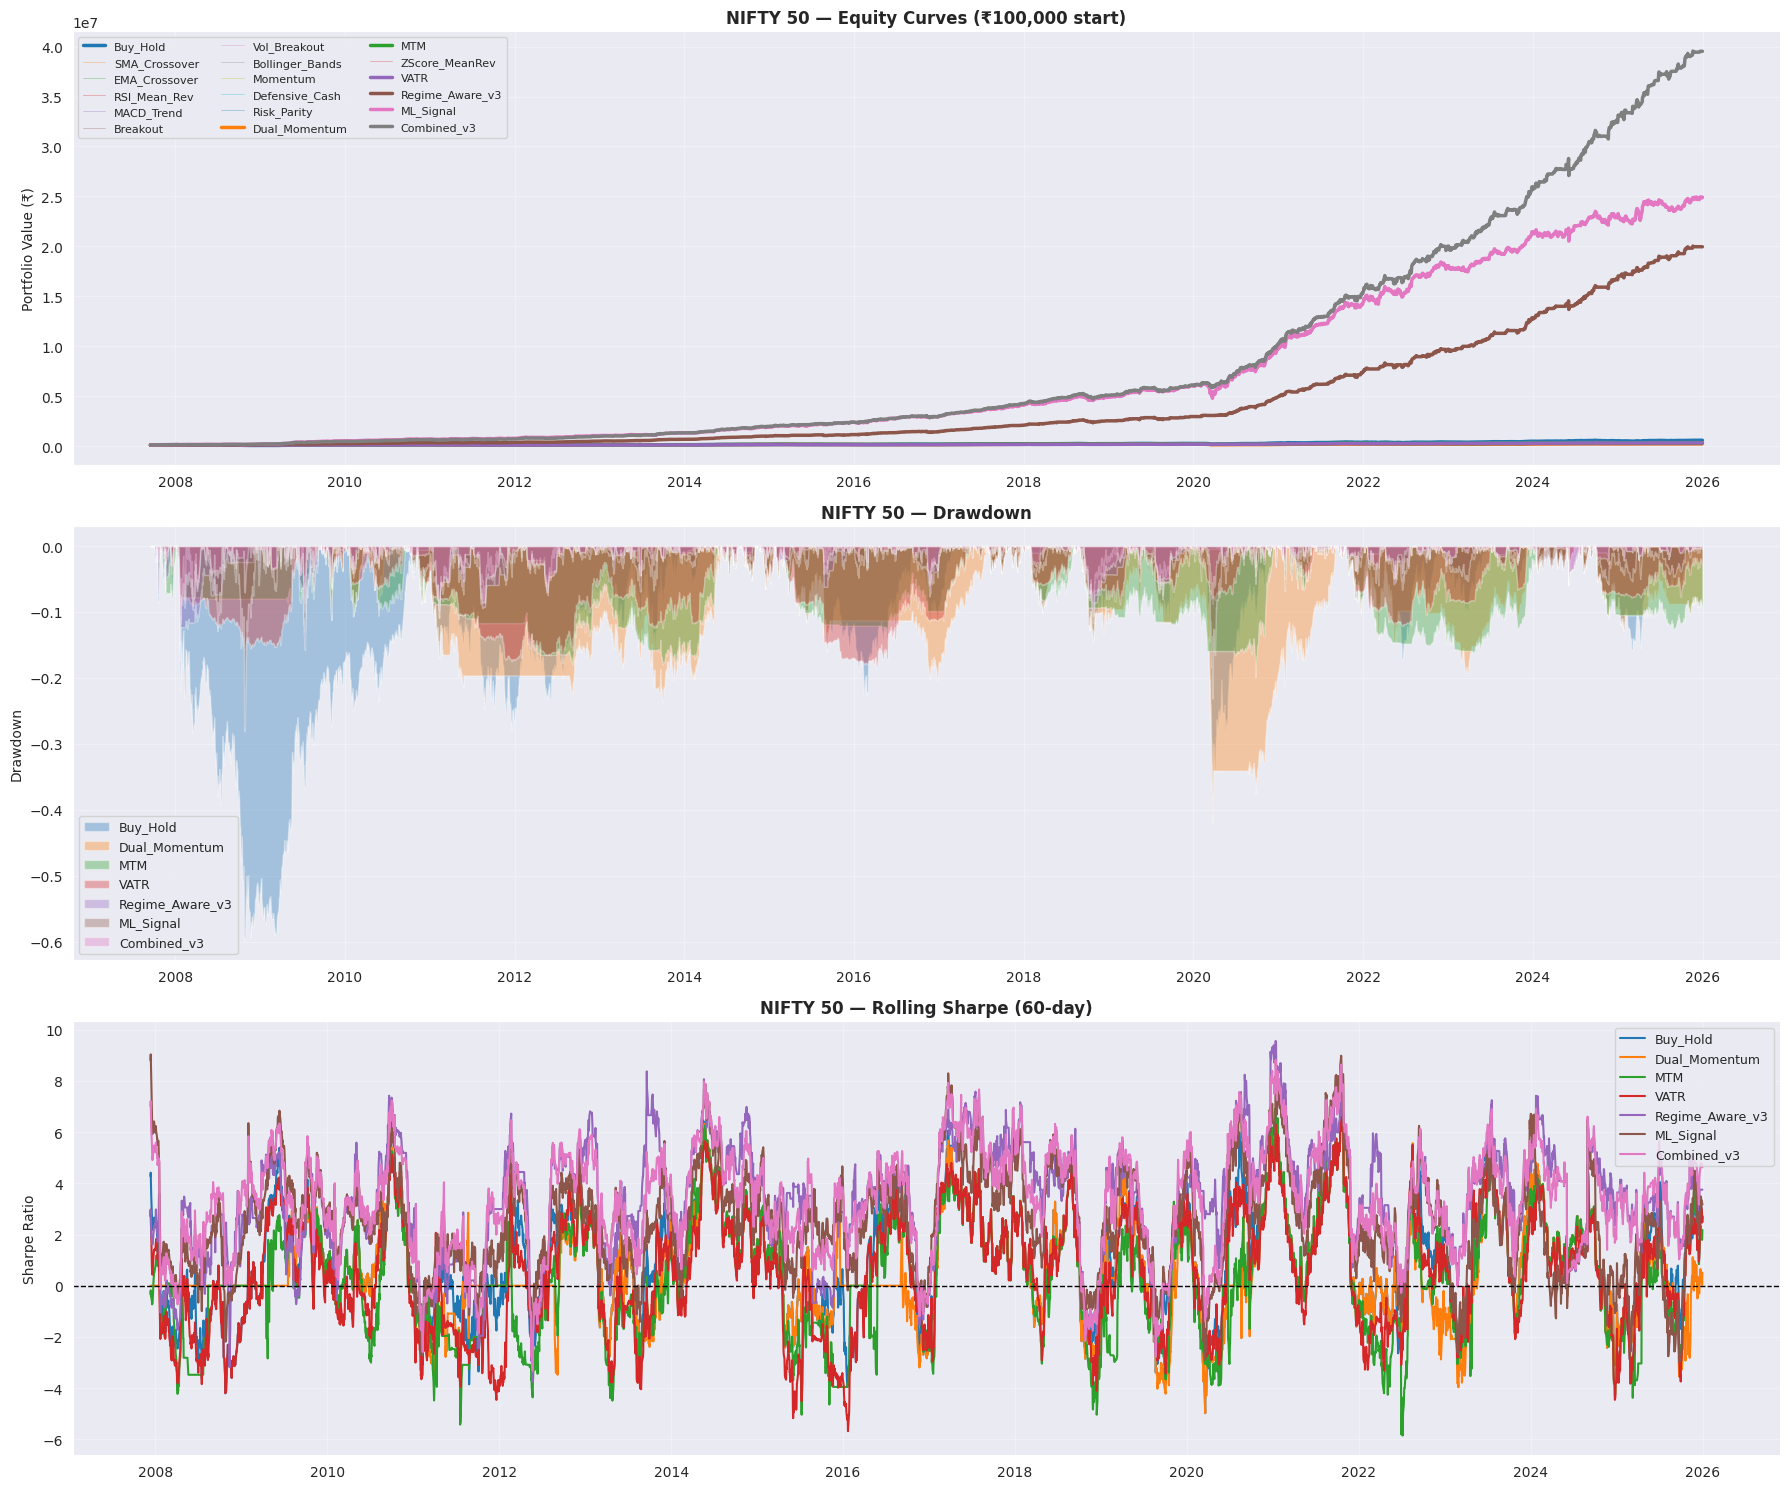

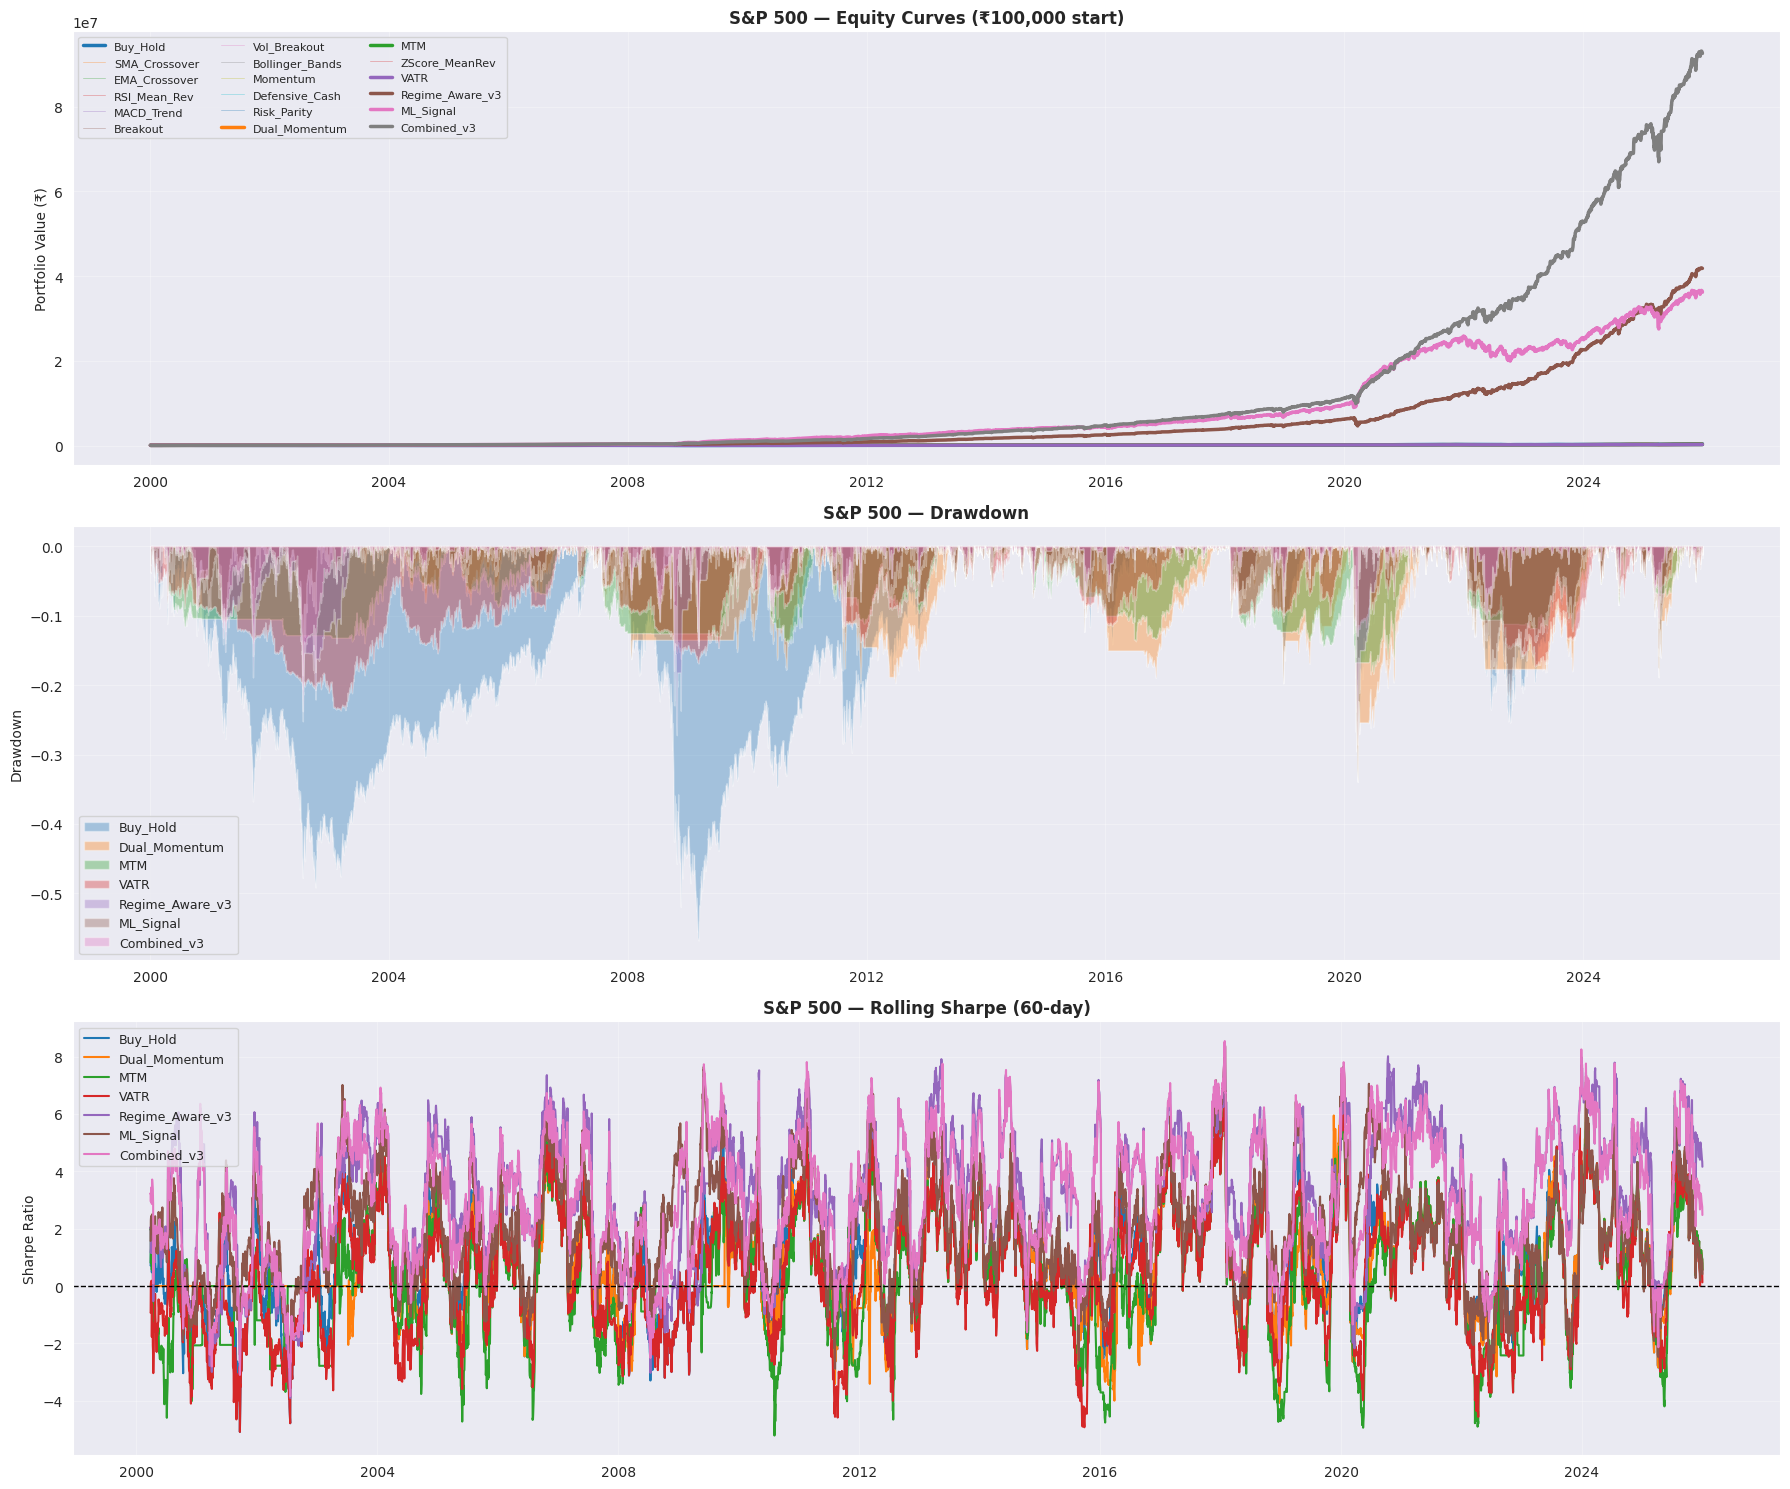

In [ ]:
# ============================================================
# SECTION 8.3 — Equity Curves, Drawdowns & Rolling Sharpe
# ============================================================

def plot_backtest_charts(strat_returns, label='Asset',
                          highlight=None, initial_capital=INITIAL_CAPITAL):
    if highlight is None:
        highlight = ['Buy_Hold','Dual_Momentum','MTM','VATR','Regime_Aware_v3','ML_Signal','Combined_v3']

    cum = (1 + strat_returns).cumprod() * initial_capital
    fig, axes = plt.subplots(3,1,figsize=(18,15))

    # Equity curves
    for col in strat_returns.columns:
        lw = 2.5 if col in highlight else 0.7
        al = 1.0 if col in highlight else 0.3
        axes[0].plot(cum.index, cum[col], label=col, linewidth=lw, alpha=al)
    axes[0].set_title(f'{label} — Equity Curves (₹{initial_capital:,} start)', fontweight='bold')
    axes[0].set_ylabel('Portfolio Value (₹)'); axes[0].legend(ncol=3, fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Drawdowns
    for col in highlight:
        if col not in strat_returns.columns: continue
        c  = (1+strat_returns[col]).cumprod()
        dd = (c - c.cummax()) / c.cummax()
        axes[1].fill_between(dd.index, dd, 0, alpha=0.35, label=col)
    axes[1].set_title(f'{label} — Drawdown', fontweight='bold')
    axes[1].set_ylabel('Drawdown'); axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    # Rolling Sharpe
    for col in highlight:
        if col not in strat_returns.columns: continue
        r  = strat_returns[col]
        rs = r.rolling(60).mean() / (r.rolling(60).std()+1e-9) * np.sqrt(252)
        axes[2].plot(rs.index, rs, label=col, linewidth=1.5)
    axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[2].set_title(f'{label} — Rolling Sharpe (60-day)', fontweight='bold')
    axes[2].set_ylabel('Sharpe Ratio'); axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{label.replace(" ","_")}_backtest.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_backtest_charts(nifty_strat_returns, 'NIFTY 50', initial_capital=INITIAL_CAPITAL)
plot_backtest_charts(sp500_strat_returns, 'S&P 500',  initial_capital=INITIAL_CAPITAL)

In [ ]:

print('NIFTY 50 — Investment Simulation')
for strat in ['Buy_Hold','Dual_Momentum','MTM','ZScore_MeanRev','VATR',
              'Regime_Aware_v3','ML_Signal','Combined_v3']:
    if strat in nifty_strat_returns.columns:
        print_investment_result(
            simulate_investment(INITIAL_CAPITAL, nifty_strat_returns[strat]),
            f'NIFTY - {strat}')

print('\nS&P 500 — Investment Simulation')
for strat in ['Buy_Hold','Dual_Momentum','MTM','ZScore_MeanRev','VATR',
              'Regime_Aware_v3','ML_Signal','Combined_v3']:
    if strat in sp500_strat_returns.columns:
        print_investment_result(
            simulate_investment(INITIAL_CAPITAL, sp500_strat_returns[strat]),
            f'SP500 - {strat}')


NIFTY 50 — Investment Simulation

───────────────────────────────────────────────────────
   Investment Simulation Results [NIFTY - Buy_Hold]
   Period: 2007-09-17 → 2025-12-31 (4487 days)
───────────────────────────────────────────────────────
  Initial Capital   : ₹  100,000.00
  Final Value       : ₹  581,348.94
  Profit / Loss     : ₹+ 481,348.94  (+481.35%)
  CAGR              :  +10.39%
  Ann. Volatility   :   20.71%
  Sharpe Ratio      :    0.345
  Sortino Ratio     :    0.338
  Max Drawdown      :  -59.86%
  Calmar Ratio      :    0.174
  Win Rate          :   53.06%
  Profit Factor     :    1.117
  Best Day          :  +17.74%
  Worst Day         :  -12.98%
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
   Investment Simulation Results [NIFTY - Dual_Momentum]
   Period: 2007-09-17 → 2025-12-31 (4487 days)
───────────────────────────────────────────────────────
  Initial Capital   : ₹  100,000.00
  Final Value   

# SECTION 12 — PORTFOLIO ALLOCATION

 Common dates for portfolio: 4365 days (2007-09-17 → 2025-12-31)

 Portfolio Allocation Comparison:


,Cumulative Return (%),Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Win Rate (%),Profit Factor,Alpha (Ann.),Beta,Final Value
Portfolio,,,,,,,,,,,,
Equal_Weight,339.82,8.93,16.27,0.307,0.295,-54.05,0.165,55.33,1.124,N/A,N/A,"₹439,823"
Risk_Parity,311.33,8.51,16.01,0.286,0.265,-54.43,0.156,55.12,1.120,N/A,N/A,"₹411,330"
Regime_Allocation,506.00,10.96,17.00,0.410,0.434,-53.54,0.205,55.23,1.144,N/A,N/A,"₹606,002"
Smart_Combined,23221.21,36.99,10.17,2.668,4.476,-12.71,2.911,58.65,1.917,N/A,N/A,"₹23,321,208"


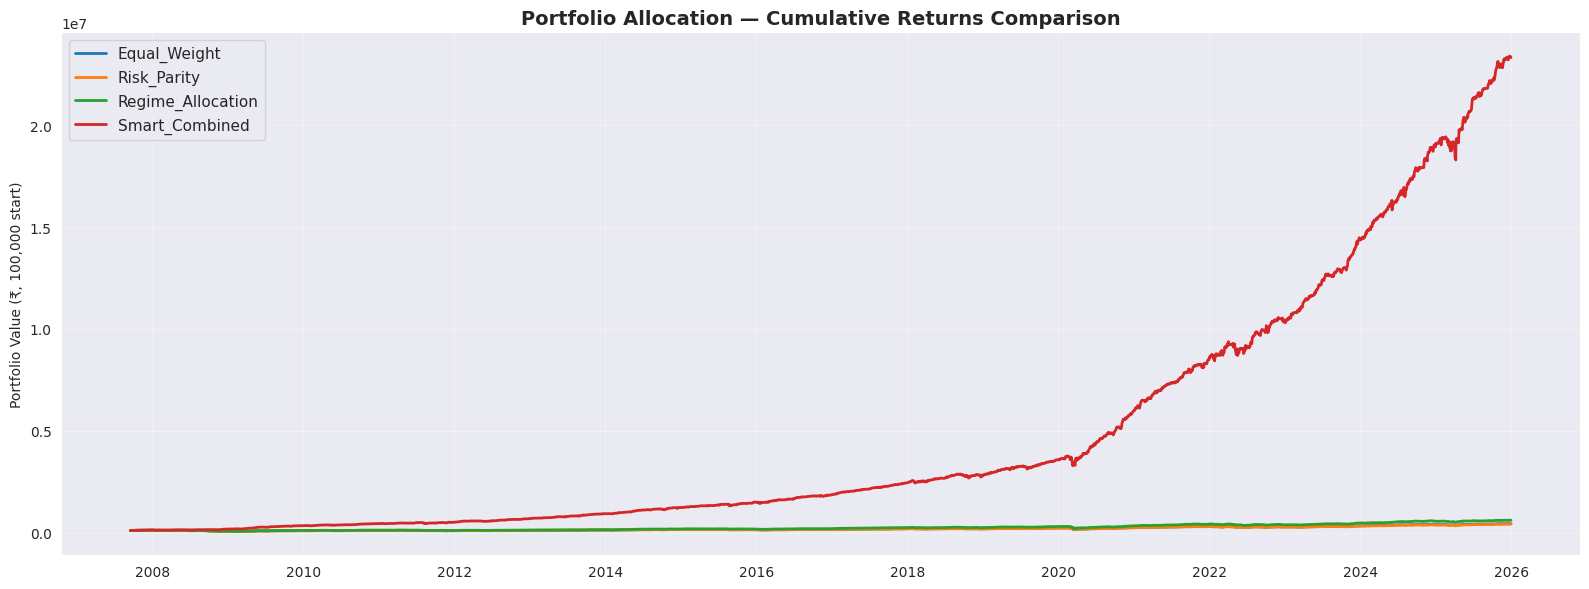

In [ ]:
# ============================================================
# SECTION 9.1 — Portfolio Allocation Comparison
# Date alignment happens HERE — not before.
# Each HMM was trained on its own full history.
# ============================================================

# Align on common dates ONLY for portfolio construction
common_idx = nifty_strat_returns.index.intersection(sp500_strat_returns.index)
nifty_bh   = nifty_strat_returns.loc[common_idx, 'Buy_Hold'].rename('NIFTY')
sp500_bh   = sp500_strat_returns.loc[common_idx, 'Buy_Hold'].rename('SP500')
nifty_regime_aligned = df_nifty_feat['regime'].reindex(common_idx).ffill()

print(f' Common dates for portfolio: {len(common_idx)} days '
      f'({common_idx[0].date()} → {common_idx[-1].date()})')

port_returns = pd.DataFrame(index=common_idx)

# 1. Equal Weight
port_returns['Equal_Weight'] = 0.5*nifty_bh + 0.5*sp500_bh

# 2. Risk Parity
vol1 = nifty_bh.rolling(60).std().bfill()
vol2 = sp500_bh.rolling(60).std().bfill()
w1   = (1/vol1) / (1/vol1 + 1/vol2)
w2   = 1 - w1
port_returns['Risk_Parity'] = w1.shift(1).fillna(0.5)*nifty_bh + w2.shift(1).fillna(0.5)*sp500_bh

# 3. Regime-Based Allocation (6-state aware)
w_n = nifty_regime_aligned.map({
    'Strong Bull': 0.75, 'Weak Bull': 0.65,
    'Strong Sideways': 0.50, 'Weak Sideways': 0.55,
    'Weak Bear': 0.35, 'Strong Bear': 0.25
}).fillna(0.5)
w_s = 1 - w_n
port_returns['Regime_Allocation'] = w_n.shift(1).fillna(0.5)*nifty_bh + w_s.shift(1).fillna(0.5)*sp500_bh

# Smart Combined: uses Combined_v3 from each index
nifty_cv3  = nifty_strat_returns.loc[common_idx, 'Combined_v3'] if 'Combined_v3' in nifty_strat_returns.columns else nifty_bh
sp500_cv3  = sp500_strat_returns.loc[common_idx, 'Combined_v3'] if 'Combined_v3' in sp500_strat_returns.columns else sp500_bh
port_returns['Smart_Combined'] = 0.5 * nifty_cv3 + 0.5 * sp500_cv3

port_returns.dropna(inplace=True)

# Metrics
port_rows = []
for col in port_returns.columns:
    m = compute_metrics(port_returns[col])
    sim = simulate_investment(INITIAL_CAPITAL, port_returns[col])
    m['Final Value'] = f'₹{sim["final_value"]:,.0f}'
    m['Portfolio'] = col
    port_rows.append(m)
port_metrics_df = pd.DataFrame(port_rows).set_index('Portfolio')

print('\n Portfolio Allocation Comparison:')
display(port_metrics_df)

# Plot
cum_port = (1+port_returns).cumprod() * INITIAL_CAPITAL
fig, ax  = plt.subplots(figsize=(16,6))
for col in cum_port.columns:
    ax.plot(cum_port.index, cum_port[col], label=col, linewidth=2)
ax.set_title('Portfolio Allocation — Cumulative Returns Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel(f'Portfolio Value (₹, {INITIAL_CAPITAL:,} start)')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('quantwise_outputs/portfolio_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# SECTION 13 — WALK-FORWARD VALIDATION (80/20)


Walk-Forward [NIFTY 50]
  Train: 2007-09-17 to 2022-05-16 (3589 = 80%)
  Test:  2022-05-17 to 2025-12-31 (898 = 20%)

Data-driven strategy selection [NIFTY 50 WF]:
  Regime               Best Strategy          Sharpe   AnnRet   Days
  -----------------------------------------------------------------
  Strong Bull          Momentum                3.234    45.7%   1193
  Weak Bull            Risk_Parity             2.662    94.4%    372
  Strong Sideways      ZScore_MeanRev          0.748     4.4%    630
  Weak Sideways        ZScore_MeanRev          2.039    20.6%    710
  Weak Bear            ZScore_MeanRev         -1.300   -16.3%    513
  Strong Bear          EMA_Crossover          -1.549   -23.2%    171
[NIFTY 50 WF] Regime_Aware_v3  Ann: 17.07%  Sharpe: 2.245

Test Period Performance:


,Cumulative Return (%),Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Win Rate (%),Profit Factor,Alpha (Ann.),Beta,Final Value
Strategy,,,,,,,,,,,,
Buy_Hold,64.94,15.08,12.57,0.792,1.124,-15.77,0.956,54.12,1.227,N/A,N/A,"Rs164,936"
Regime_Aware_WF,73.80,16.78,7.02,1.550,2.735,-3.96,4.241,54.12,2.035,N/A,N/A,"Rs173,798"
ML_WF,62.41,14.58,9.22,0.993,1.418,-6.24,2.336,53.34,1.322,N/A,N/A,"Rs162,415"
Combined_v3_Full,142.47,28.22,8.38,2.427,3.724,-5.93,4.760,54.12,2.019,N/A,N/A,"Rs242,472"


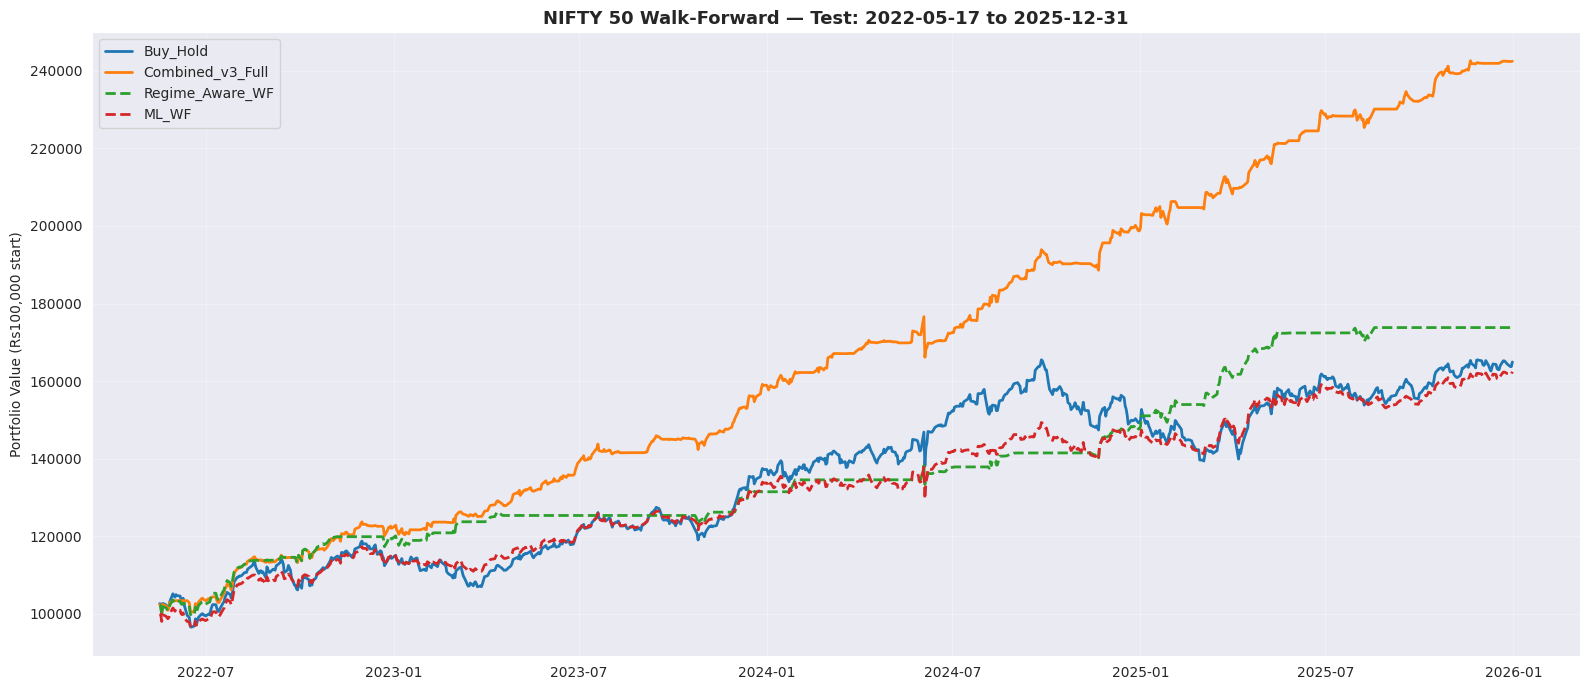


Walk-Forward [S&P 500]
  Train: 2000-01-03 to 2020-10-15 (5231 = 80%)
  Test:  2020-10-16 to 2025-12-31 (1308 = 20%)



Data-driven strategy selection [S&P 500 WF]:
  Regime               Best Strategy          Sharpe   AnnRet   Days
  -----------------------------------------------------------------
  Strong Bull          Risk_Parity             2.313    18.5%   1683
  Weak Bull            Defensive_Cash          1.787    26.3%    771
  Strong Sideways      ZScore_MeanRev          0.924     5.9%    944
  Weak Sideways        ZScore_MeanRev          2.396    21.6%    526
  Weak Bear            ZScore_MeanRev         -0.574    -7.8%    708
  Strong Bear          ZScore_MeanRev         -0.305    -9.9%    599
[S&P 500 WF] Regime_Aware_v3  Ann: 13.36%  Sharpe: 0.879

Test Period Performance:


,Cumulative Return (%),Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Win Rate (%),Profit Factor,Alpha (Ann.),Beta,Final Value
Strategy,,,,,,,,,,,,
Buy_Hold,96.52,13.90,16.92,0.565,0.720,-25.43,0.547,53.82,1.163,N/A,N/A,"Rs196,521"
Regime_Aware_WF,81.86,12.21,14.27,0.537,0.662,-17.99,0.679,53.82,1.181,N/A,N/A,"Rs181,857"
ML_WF,99.01,14.18,14.49,0.651,0.840,-22.63,0.627,53.06,1.197,N/A,N/A,"Rs199,012"
Combined_v3_Full,401.60,36.44,12.55,2.150,3.398,-11.80,3.087,53.82,1.747,N/A,N/A,"Rs501,599"


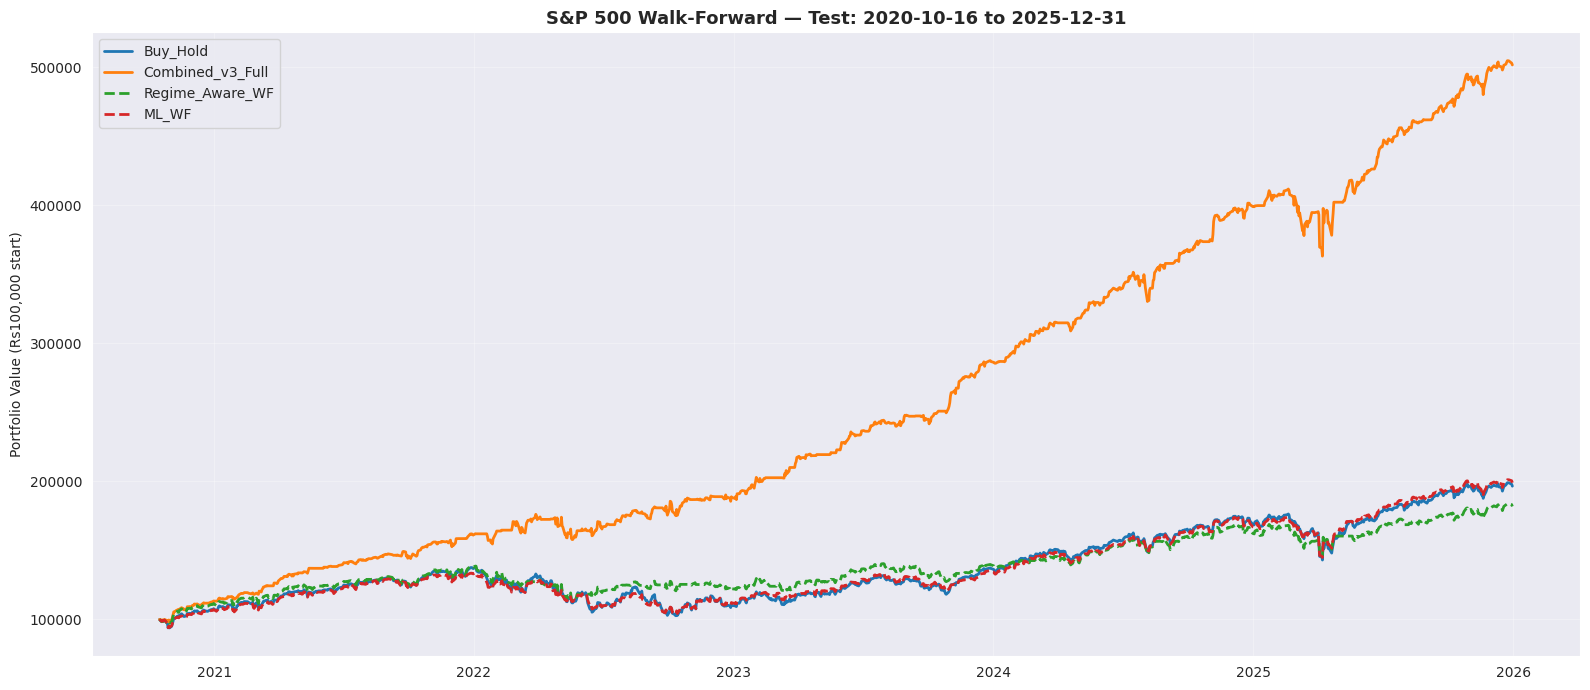

In [ ]:

def walk_forward_80_20(df_feat, strat_returns, hmm_full, label='Asset'):
    n_total  = len(df_feat)
    n_train  = int(n_total * 0.8)
    train_df = df_feat.iloc[:n_train]
    test_df  = df_feat.iloc[n_train:]

    print(f'\nWalk-Forward [{label}]')
    print(f'  Train: {train_df.index[0].date()} to {train_df.index[-1].date()} ({n_train} = 80%)')
    print(f'  Test:  {test_df.index[0].date()} to {test_df.index[-1].date()} ({len(test_df)} = 20%)')

    HMM_FEATS = ['log_return','vol_10','vol_20','rsi_14','macd_diff',
                  'bb_pct','vol_ratio','trend_strength']
    HMM_FEATS = [f for f in HMM_FEATS if f in df_feat.columns]

    # Train HMM on 80%
    model_wf = GaussianHMM(n_components=6, covariance_type='diag',
                             n_iter=2000, random_state=RANDOM_SEED)
    model_wf.fit(train_df[HMM_FEATS].values)

    # Regime map from training data
    train_states = model_wf.predict(train_df[HMM_FEATS].values)
    rstats = {}
    for s in range(6):
        mask  = (train_states == s)
        sdata = train_df.loc[train_df.index[mask]]
        rstats[s] = {'mean_return': float(sdata['daily_return'].mean()),
                     'mean_vol':    float(sdata['vol_20'].mean())}
    all_rets = [v['mean_return'] for v in rstats.values()]
    all_vols = [v['mean_vol']    for v in rstats.values()]
    wf_rmap  = {s: classify_6state(rstats[s],
                    np.percentile(all_rets,67), np.percentile(all_rets,33),
                    np.percentile(all_vols,75), np.percentile(all_vols,50))
                for s in range(6)}

    test_states = model_wf.predict(test_df[HMM_FEATS].values)
    test_df_c   = test_df.copy()
    raw_reg     = pd.Series([wf_rmap[s] for s in test_states],
                             index=test_df_c.index, name='regime')
    test_df_c['regime'] = smooth_regimes(raw_reg, min_days=10)

    train_strat = strat_returns.loc[:train_df.index[-1]]
    test_strat  = strat_returns.loc[test_df_c.index[0]:]

    # Data-driven best map on TRAINING period only
    wf_best_map, _ = find_best_strategy_per_regime(
        train_df, train_strat, HIGH_ALPHA_POOL, f'{label} WF')

    # Regime_Aware_v3 on TEST
    wf_regime_v3 = compute_regime_aware_v3(
        test_df_c, test_strat, model_wf, wf_best_map, f'{label} WF')

    # ML walk-forward (train on 80%, predict on 20%)
    feats     = [f for f in ML_FEATURES if f in df_feat.columns]
    y_all     = (df_feat['daily_return'].shift(-1) > 0).astype(int)
    X_all     = df_feat[feats].replace([np.inf,-np.inf], 0).fillna(0)
    X_tr      = X_all.iloc[:n_train-1]
    y_tr      = y_all.iloc[:n_train-1]
    X_te      = X_all.iloc[n_train:]
    sc_wf     = StandardScaler()
    rf_wf     = RandomForestClassifier(n_estimators=100, max_depth=5,
                                        random_state=RANDOM_SEED, n_jobs=-1)
    rf_wf.fit(sc_wf.fit_transform(X_tr), y_tr)
    p_wf      = rf_wf.predict_proba(sc_wf.transform(X_te))[:,1]
    prob_wf   = pd.Series(p_wf, index=X_te.index)
    pos_wf    = ((prob_wf - 0.45) / 0.10).clip(0,1).shift(1).fillna(0)
    ml_wf_ret = (pos_wf * test_strat['Buy_Hold'].reindex(pos_wf.index).fillna(0)).rename('ML_WF')

    bh_ret   = strat_returns.loc[test_df_c.index[0]:, 'Buy_Hold']
    cv3_ret  = strat_returns.loc[test_df_c.index[0]:, 'Combined_v3']                if 'Combined_v3' in strat_returns.columns else bh_ret

    rows = []
    for name, series in [('Buy_Hold',         bh_ret),
                          ('Regime_Aware_WF',  wf_regime_v3),
                          ('ML_WF',            ml_wf_ret),
                          ('Combined_v3_Full', cv3_ret)]:
        m   = compute_metrics(series)
        sim = simulate_investment(INITIAL_CAPITAL, series)
        m['Final Value'] = f'Rs{sim["final_value"]:,.0f}'
        m['Strategy']    = name
        rows.append(m)

    wf_df = pd.DataFrame(rows).set_index('Strategy')
    print(f'\nTest Period Performance:')
    display(wf_df)

    fig, ax = plt.subplots(figsize=(16,7))
    for name, series in [('Buy_Hold', bh_ret), ('Combined_v3_Full', cv3_ret),
                          ('Regime_Aware_WF', wf_regime_v3), ('ML_WF', ml_wf_ret)]:
        ls = '--' if 'WF' in name else '-'
        eq = simulate_investment(INITIAL_CAPITAL, series)['equity_curve']
        ax.plot(eq.index, eq, label=name, linewidth=2, linestyle=ls)
    ax.set_title(f'{label} Walk-Forward — Test: {test_df_c.index[0].date()} to {test_df_c.index[-1].date()}',
                  fontsize=13, fontweight='bold')
    ax.set_ylabel(f'Portfolio Value (Rs{INITIAL_CAPITAL:,} start)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    os.makedirs('quantwise_outputs', exist_ok=True)
    plt.savefig(f'quantwise_outputs/{label.replace(" ","_")}_walkforward.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    return wf_df


wf_nifty = walk_forward_80_20(df_nifty_feat, nifty_strat_returns, hmm_nifty, 'NIFTY 50')
wf_sp500 = walk_forward_80_20(df_sp500_feat, sp500_strat_returns, hmm_sp500, 'S&P 500')


# SECTION 14 — FINAL REPORT

In [ ]:

def generate_final_report(nifty_bt, sp500_bt, port_metrics_df, nifty_feat, sp500_feat):
    print('='*70)
    print('  QuantWise v3 — Final Research Report')
    print('='*70)
    print(f'  Generated : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    print(f'  Capital   : Rs{INITIAL_CAPITAL:,}')

    for label, bt in [('NIFTY 50', nifty_bt), ('S&P 500', sp500_bt)]:
        print(f'\n{label} — Rankings (by Sharpe):')
        cols = ['Ann. Return (%)','Ann. Volatility (%)','Sharpe Ratio',
                'Max Drawdown (%)','Win Rate (%)']
        cols = [c for c in cols if c in bt.columns]
        print(bt.sort_values('Sharpe Ratio', ascending=False)[cols].to_string())

    print('\nPortfolio Allocation:')
    pcols = ['Ann. Return (%)','Sharpe Ratio','Max Drawdown (%)','Final Value']
    pcols = [c for c in pcols if c in port_metrics_df.columns]
    print(port_metrics_df[pcols].to_string())

    print('\n6-State Regime Distribution:')
    for lbl, feat_df in [('NIFTY 50', nifty_feat), ('S&P 500', sp500_feat)]:
        print(f'  {lbl}:')
        for r in REGIME_COLORS:
            c = (feat_df['regime'] == r).sum()
            if c > 0:
                print(f'    {r:<20}: {c:5d} days ({c/len(feat_df)*100:.1f}%)')

    best_n = nifty_bt['Sharpe Ratio'].idxmax() if 'Sharpe Ratio' in nifty_bt.columns else 'N/A'
    best_s = sp500_bt['Sharpe Ratio'].idxmax() if 'Sharpe Ratio' in sp500_bt.columns else 'N/A'
    print(f"""
{"-"*70}
  v3 Changes
{"-"*70}
  Phase 1 — 4 High-Alpha Strategies added:
    Dual_Momentum  : Absolute + relative momentum (12m lookback, monthly rebalance)
    MTM            : AQR-style 1m/3m/6m/12m weighted composite momentum
    ZScore_MeanRev : Statistically grounded mean reversion (entry < -2 std)
    VATR           : ATR-sized position on EMA crossover trend signal

  Phase 2 — Data-Driven Regime Switching:
    Best strategy per regime selected by per-regime Sharpe (not manual guessing)
    HMM confidence probability used as daily blend weight
    High confidence day -> near 100% in best strategy for that regime
    Low confidence day  -> weighted blend across all regimes proportionally

  Phase 3 — ML Ensemble Signal:
    Ensemble: LogisticRegression + RandomForest + GradientBoosting
    Adaptive alpha: ML weight scales with rolling 30-day prediction accuracy
    Combined_v3 = alpha * ML_Signal + (1-alpha) * Regime_Aware_v3

  Best by Sharpe NIFTY 50 : {best_n}
  Best by Sharpe S&P 500  : {best_s}
""")
    print('='*70)

generate_final_report(nifty_bt, sp500_bt, port_metrics_df, df_nifty_feat, df_sp500_feat)


  QuantWise v3 — Final Research Report
  Generated : 2026-03-02 15:04:59
  Capital   : Rs100,000

NIFTY 50 — Rankings (by Sharpe):
                 Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%)  Win Rate (%)
Strategy                                                                                           
Combined_v3                39.91                12.27         2.402            -15.95         53.06
Regime_Aware_v3            34.64                11.57         2.207            -17.42         53.06
ML_Signal                  36.33                15.93         1.720            -28.13         52.69
Momentum                    9.12                12.97         0.361            -30.96         32.58
EMA_Crossover               9.12                13.39         0.354            -26.17         35.59
Buy_Hold                   10.39                20.71         0.345            -59.86         53.06
Defensive_Cash              8.38                15.71         0.280  

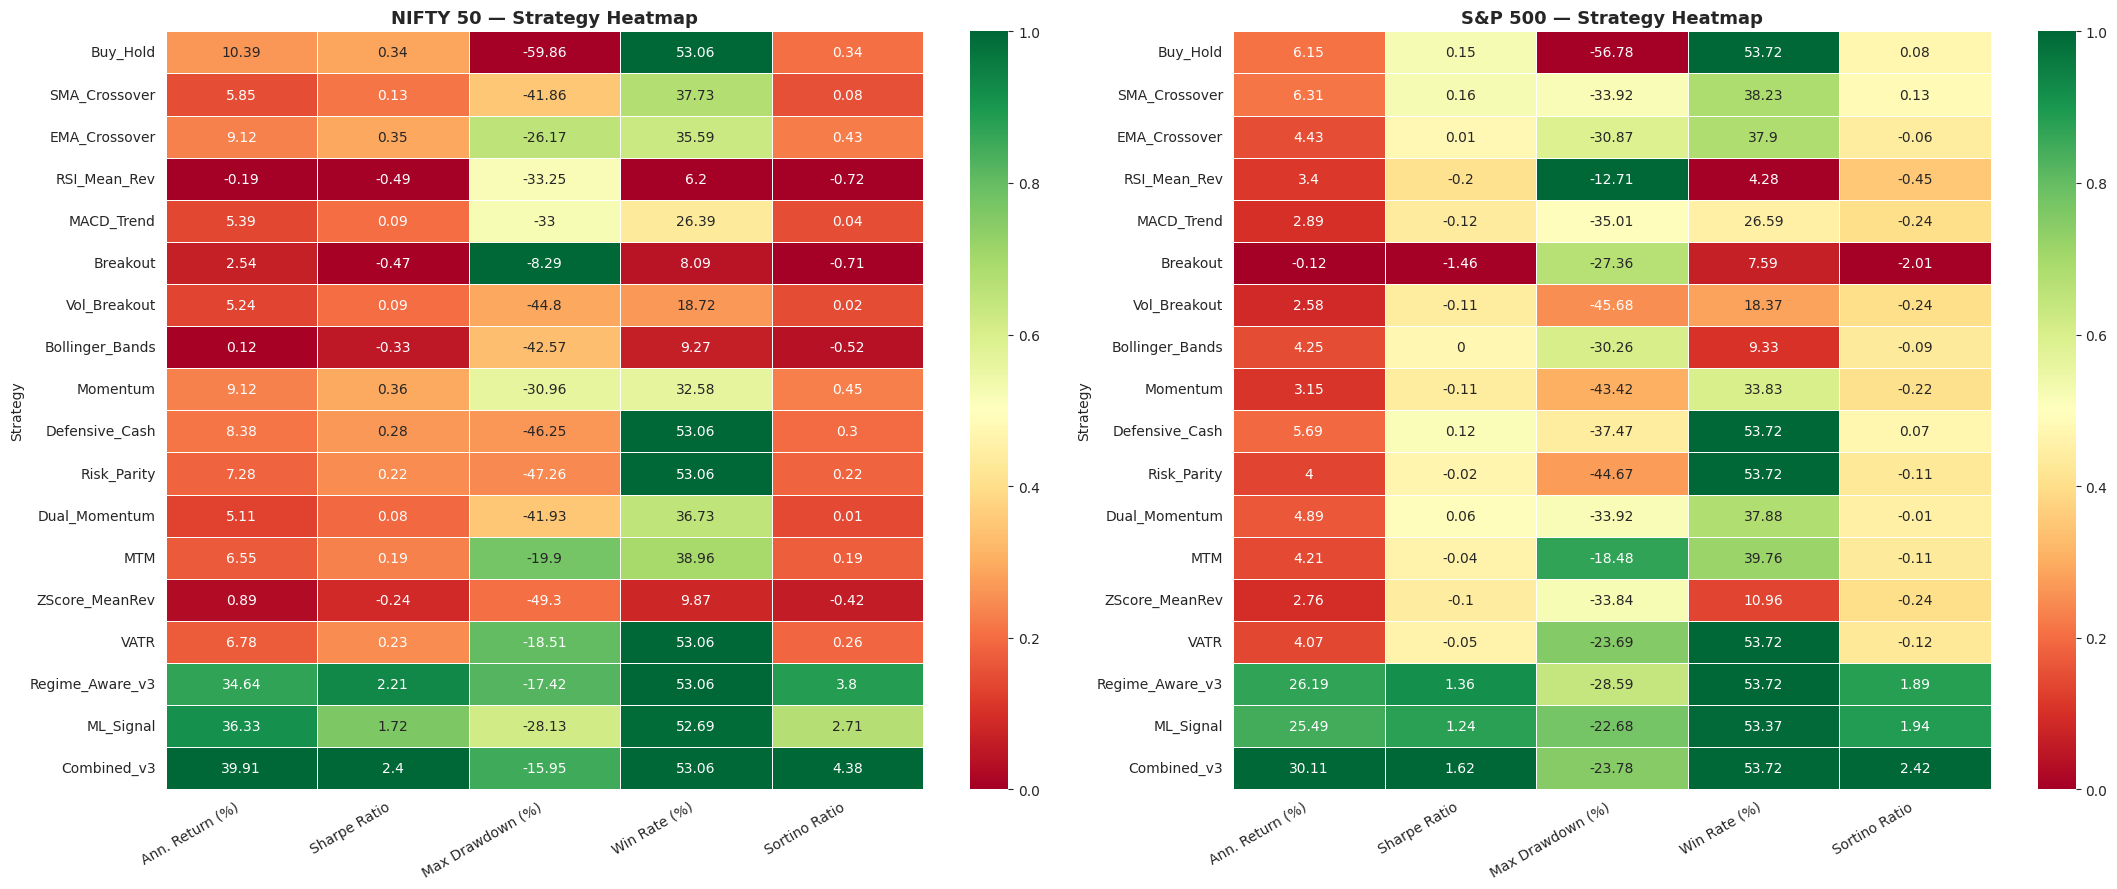

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(22,9))
for ax, bt_df, label in [(axes[0],nifty_bt,'NIFTY 50'),(axes[1],sp500_bt,'S&P 500')]:
    cols = ['Ann. Return (%)','Sharpe Ratio','Max Drawdown (%)','Win Rate (%)','Sortino Ratio']
    cols = [c for c in cols if c in bt_df.columns]
    data = bt_df[cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    norm = (data - data.min()) / (data.max() - data.min() + 1e-9)
    sns.heatmap(norm, annot=data.round(2), fmt='g', cmap='RdYlGn',
                ax=ax, linewidths=0.5)
    ax.set_title(f'{label} — Strategy Heatmap', fontsize=13, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('quantwise_outputs/final_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()